# Phần 1. INTRODUCTION

**Bối cảnh**

Trong bối cảnh thương mại điện tử ngày càng cạnh tranh, doanh nghiệp không chỉ cần thu hút traffic mà còn phải **hiểu hành vi người dùng và tối ưu toàn bộ hành trình từ xem sản phẩm đến mua hàng**. Việc phân tích dữ liệu hành vi giúp xác định sản phẩm có giá trị, điểm thất thoát trong funnel và các tín hiệu có thể thúc đẩy conversion.

Nguồn dữ liệu: [eCommerce behavior data from multi category store](https://www.kaggle.com/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store) - Bộ dữ liệu ghi nhận hành vi người dùng trên một cửa hàng thương mại điện tử đa danh mục, bao gồm các event như view, cart, remove_from_cart và purchase, cùng thông tin về sản phẩm, thương hiệu, giá, khách hàng và session.

**Mục tiêu dự án**

Dự án này sử dụng các kỹ thuật phân tích dữ liệu để:

* Phân tích traffic, revenue và hành vi mua hàng theo thời gian.

* Xác định category, brand và product đang tạo ra nhiều giá trị.

* Phân tích conversion funnel và xác định điểm thất thoát lớn nhất.

* Đánh giá mối quan hệ giữa price và conversion.

* Phân tích customer value và xác định nhóm khách hàng cần reactivation.

* Xác định các session behavior có thể báo hiệu purchase intent.

* Sử dụng Interest × Conversion để ưu tiên nguồn lực và recommendation.

## Business Questions

Trước khi bắt đầu phân tích dữ liệu, cần xác định các câu hỏi kinh doanh cần được trả lời. Những câu hỏi này sẽ đóng vai trò định hướng cho toàn bộ quá trình Exploratory Data Analysis (EDA) và giúp đảm bảo rằng các kết quả phân tích đều phục vụ cho việc hỗ trợ ra quyết định.

**Traffic và Revenue**

* Traffic và revenue thay đổi như thế nào theo thời gian?

* Có những thời điểm traffic cao nhưng conversion hoặc revenue thấp hay không?

**Category, Brand và Product**

* Category, brand và product nào đang tạo ra nhiều giá trị nhất?

* Nhóm nào có interest cao nhưng conversion thấp và ngược lại?

**Funnel**

* Funnel từ view → cart → purchase thất thoát lớn nhất ở đâu?

* Những category hoặc product nào có funnel tốt hoặc kém?

**Price và Conversion**

* Price ảnh hưởng thế nào đến conversion?

* Mức giá nào có xu hướng tạo ra conversion tốt hơn?

**Customer**

* Customer nào có giá trị cao?

* Những customer nào có dấu hiệu cần reactivation?

**Session Behavior**

* Session behavior nào có thể báo hiệu purchase intent?

* Những hành vi nào thường xuất hiện trước purchase?

**Next-Day Purchase Prediction**

* Với khách active ngày D, ai có khả năng purchase trong ngày D+1?

**Interest × Conversion**

* Có thể sử dụng Interest × Conversion để ưu tiên nguồn lực cho category, brand và product như thế nào?

* Framework này có thể hỗ trợ recommendation strategy ra sao?

**Expected Outcome**

Thông qua việc trả lời các câu hỏi trên, kỳ vọng có thể **xác định được những insight quan trọng** về traffic, product performance, conversion funnel và customer behavior, đồng thời **đề xuất các hướng ưu tiên cho marketing, reactivation và recommendation.**


# Phần 2. LOADING AND EDA


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%pip -q install "duckdb>=1.4,<2" "pandas>=2.2,<3" "pyarrow>=18"

# ============================================================
# SETUP
# ============================================================

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Path to Parquet file
# ------------------------------------------------------------
parquet_path = "/content/drive/MyDrive/CoderSchool Exercises /Final Project | Kaggle Data/LeVietDang | Final Project/FinalProject/data/2019-Oct.parquet"

# ------------------------------------------------------------
# Create DuckDB connection
# ------------------------------------------------------------
con = duckdb.connect()

# Optional:
# Giới hạn DuckDB dùng tối đa khoảng 6GB RAM
# Có thể giảm xuống 4GB nếu Colab RAM thấp
con.execute("SET memory_limit='6GB'")

# Cho phép DuckDB dùng disk khi query lớn
con.execute("""
SET temp_directory='/content/duckdb_temp'
""")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 48.6 MB/s eta 0:00:00


In [3]:
import os

# Extract the directory path from parquet_path
dir_path = os.path.dirname(parquet_path)

print(f"Listing contents of: {dir_path}")

# List the contents of the directory
if os.path.exists(dir_path):
    for item in os.listdir(dir_path):
        print(item)
else:
    print(f"Directory does not exist: {dir_path}")

Listing contents of: /content/drive/MyDrive/CoderSchool Exercises /Final Project | Kaggle Data/LeVietDang | Final Project/FinalProject/data
2019-Nov.csv
2019-Oct.csv
download_data.ipynb
2019-Oct.parquet
purchase_prediction_v2
2019-Nov.parquet
OUTPUT_DIR = 
content


In [4]:
query = f"""
SELECT *
FROM read_parquet('{parquet_path}')
LIMIT 5
"""

con.execute(query).df()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,None,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,None,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [5]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# =========================
# E-COMMERCE CHART STYLE
# =========================

COLORS = {
    "navy": "#17324D",
    "blue": "#2F80ED",
    "teal": "#27AE9A",
    "sky": "#56CCF2",
    "orange": "#F2994A",
    "coral": "#EB5757",
    "purple": "#9B51E0",
    "gray": "#6B7280",
    "light_gray": "#E5E7EB",
    "dark": "#1F2937"
}

mpl.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 120,

    "font.family": "DejaVu Sans",
    "font.size": 11,

    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.titlepad": 15,

    "axes.labelsize": 11,
    "axes.labelcolor": COLORS["dark"],

    "xtick.color": COLORS["gray"],
    "ytick.color": COLORS["gray"],

    "axes.edgecolor": COLORS["light_gray"],
    "axes.linewidth": 0.8,

    "axes.grid": True,
    "grid.color": "#E5E7EB",
    "grid.linewidth": 0.8,
    "grid.alpha": 0.7,

    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

PALETTE = [
    COLORS["navy"],
    COLORS["blue"],
    COLORS["teal"],
    COLORS["sky"],
    COLORS["orange"],
    COLORS["coral"],
    COLORS["purple"]
]

### Tổng quan về dữ liệu | Dataset Overview

Dữ liệu được sử dụng cho phân tích EDA hành vi người dùng và hiệu quả kinh doanh trên nền tảng e-commerce. Phần này tập trung vào traffic, product/ category/ brand performance, funnel, conversion, customer value và session behavior.

Mô tả dữ liệu

Dự án sử dụng dữ liệu hành vi người dùng của một cửa hàng thương mại điện tử đa danh mục từ bộ **eCommerce behavior data from multi category store** trên Kaggle. Phạm vi phân tích là **tháng 10/2019**, thông qua file `2019-Oct.parquet`.

Dữ liệu có cấu trúc dạng bảng ở cấp độ sự kiện (**event-level**): mỗi dòng ghi nhận một hành vi của một người dùng đối với một sản phẩm tại một thời điểm. Một người dùng có thể có nhiều phiên truy cập, và mỗi phiên có thể chứa nhiều sự kiện. Vì vậy, số dòng không đồng nghĩa với số khách hàng hay số đơn hàng.

| Hạng mục | Mô tả / quy mô |
|---|---|
| File phân tích | `2019-Oct.parquet` |
| Phạm vi thời gian | Tháng 10/2019; timestamp hiển thị theo UTC |
| Quy mô sự kiện | **42.448.764**: tổng ba loại event trong output đã lưu của notebook |
| Số cột gốc | **9** |
| Các loại event đã quan sát | `view`, `cart`, `purchase` |
| Session phân biệt, không NULL | **9.244.421** |
| Session có purchase | **629.560**, tương đương **6,81%** tổng session hợp lệ |
| Khách hàng đã mua trong bảng RFM | **347.118**; không phải tổng số người dùng truy cập |
| Bảng session phục vụ EDA | **9.244.421 dòng × 13 cột** |
| Mẫu dùng cho ML | **500.000 session**; chia 400.000 train / 100.000 test, có stratification |

### Phân bố hành vi

| Event | Ý nghĩa | Số dòng trong output | Tỷ trọng trong ba loại event |
|---|---|---:|---:|
| `view` | Xem sản phẩm | 40.779.399 | 96,07% |
| `cart` | Thêm sản phẩm vào giỏ | 926.516 | 2,18% |
| `purchase` | Ghi nhận mua sản phẩm | 742.849 | 1,75% |
| **Tổng** | | **42.448.764** | **100,00%** |


### Mục tiêu phân tích

Mục tiêu là chuyển dữ liệu event-level thành các insight có thể hành động cho Business, tập trung vào:

1. Xu hướng traffic và revenue theo thời gian.
2. Category, brand và product nào được quan tâm hoặc mua nhiều.
3. Funnel thất thoát ở đâu và điểm nghẽn conversion nằm tại bước nào.
4. Mối quan hệ giữa price và conversion.
5. Customer value và segmentation theo RFM.
6. Session behavior có liên quan thế nào tới purchase.
7. Cơ hội recommendation và phân bổ ưu tiên theo interest × conversion.


# Phần 3. BUSINESS ANALYSIS

**Mục tiêu:** Hiểu hành vi người dùng, yếu tố ảnh hưởng đến conversion và revenue, từ đó tìm các cơ hội tối ưu về sản phẩm, giá, marketing và CRM.


## 3.1. Traffic và Revenue thay đổi như thế nào theo thời gian?

**Business Question:** Traffic tăng có kéo theo revenue không? Revenue peak xuất hiện khi nào? Conversion efficiency có thay đổi theo thời gian không?


In [6]:
# Aggregate theo ngày

# ============================================================
# 3.1.1 TRAFFIC & REVENUE OVER TIME
# ============================================================

query = f"""
SELECT
    CAST(event_time AS DATE) AS date,

    -- Traffic
    COUNT(*) FILTER (
        WHERE event_type = 'view'
    ) AS views,

    -- Add to cart
    COUNT(*) FILTER (
        WHERE event_type = 'cart'
    ) AS carts,

    -- Purchases
    COUNT(*) FILTER (
        WHERE event_type = 'purchase'
    ) AS purchases,

    -- Unique visitors
    COUNT(DISTINCT user_id) AS users,

    -- Revenue chỉ tính purchase
    SUM(
        CASE
            WHEN event_type = 'purchase'
            THEN price
            ELSE 0
        END
    ) AS revenue

FROM read_parquet('{parquet_path}')

GROUP BY date
ORDER BY date
"""

daily = con.execute(query).df()

daily.head()



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,date,views,carts,purchases,users,revenue
0,2019-10-01,1208280,16658,19307,190188,6275964.01
1,2019-10-02,1154591,17268,19469,184965,6213628.53
2,2019-10-03,1088725,19323,19255,170668,6233782.98
3,2019-10-04,1346320,43829,27041,209410,8623684.47
4,2019-10-05,1271348,35497,23494,194958,7341596.91


In [7]:
# Conversion từ View -> Purchase
daily["conversion_rate"] = (
    daily["purchases"] /
    daily["views"]
)

# Average Order Value
daily["avg_purchase_value"] = (
    daily["revenue"] /
    daily["purchases"]
)

daily.head()

,date,views,carts,purchases,users,revenue,conversion_rate,avg_purchase_value
0,2019-10-01,1208280,16658,19307,190188,6275964.01,0.015979,325.061584
1,2019-10-02,1154591,17268,19469,184965,6213628.53,0.016862,319.154992
2,2019-10-03,1088725,19323,19255,170668,6233782.98,0.017686,323.748791
3,2019-10-04,1346320,43829,27041,209410,8623684.47,0.020085,318.911448
4,2019-10-05,1271348,35497,23494,194958,7341596.91,0.018480,312.488163


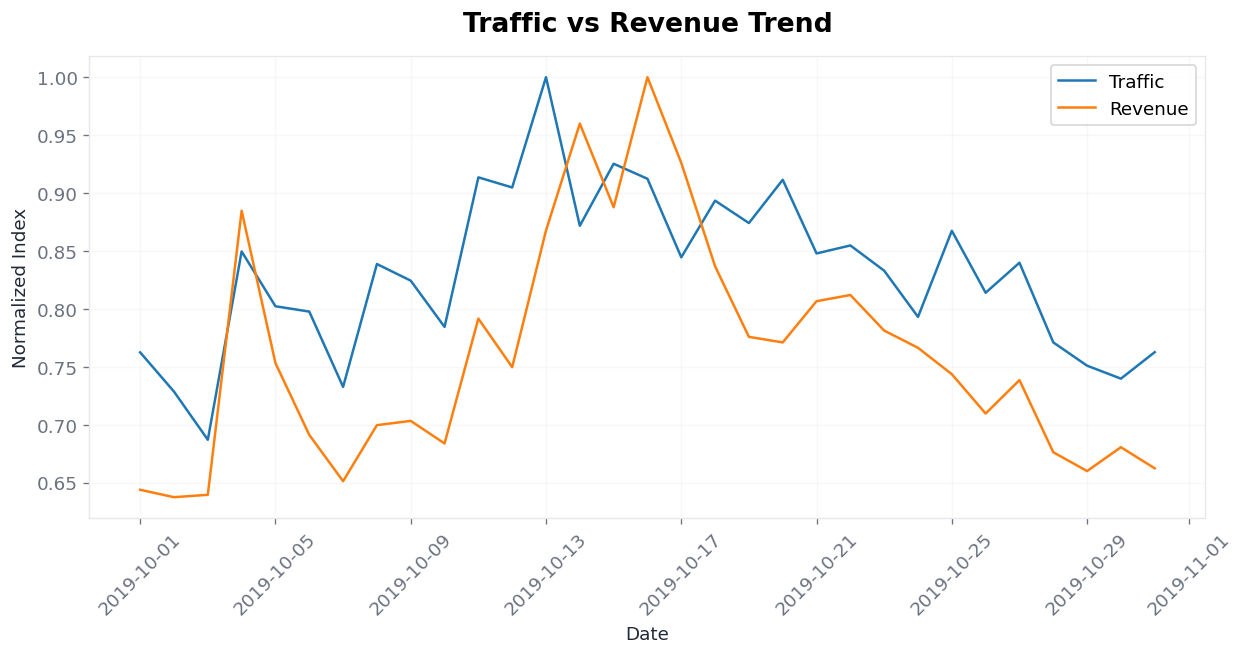

In [8]:
# 3.1.2 Traffic vs Revenue Trend


temp = daily.copy()

temp["views_index"] = (
    temp["views"] /
    temp["views"].max()
)

temp["revenue_index"] = (
    temp["revenue"] /
    temp["revenue"].max()
)

plt.figure(figsize=(12, 5))

plt.plot(
    temp["date"],
    temp["views_index"],
    label="Traffic"
)

plt.plot(
    temp["date"],
    temp["revenue_index"],
    label="Revenue"
)

plt.title("Traffic vs Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Normalized Index")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)

plt.show()






### Key Insights & Recommendations

**Key Insights**

* Traffic và Revenue nhìn chung cùng xu hướng, cho thấy traffic là driver quan trọng của doanh thu.
* Revenue đạt đỉnh sau traffic vài ngày → có thể tồn tại độ trễ từ view đến purchase.
* Cuối tháng, Revenue giảm nhanh hơn Traffic → có dấu hiệu conversion efficiency giảm.

**Recommendations**

* Kiểm tra daily conversion rate và revenue per visitor.
* Phân tích giai đoạn 12–15/10 để tìm yếu tố tạo revenue peak.
* Kiểm tra cuối tháng theo category, brand, price và funnel để xác định nguyên nhân conversion giảm.


## 3.2. Category, Brand và Product Performance

**Business Question:** Nhóm sản phẩm nào vừa thu hút traffic vừa tạo purchase và revenue tốt?


### 3.2.1. Category Analysis

Phân tích volume, revenue và conversion theo category để nhận diện revenue engines và nhóm còn dư địa tăng trưởng.


In [26]:
# ============================================================
# 2. CATEGORY ANALYSIS
# ============================================================

query = f"""
SELECT
    category_code,

    COUNT(*) FILTER (
        WHERE event_type = 'view'
    ) AS views,

    COUNT(*) FILTER (
        WHERE event_type = 'cart'
    ) AS carts,

    COUNT(*) FILTER (
        WHERE event_type = 'purchase'
    ) AS purchases,

    SUM(
        CASE
            WHEN event_type = 'purchase'
            THEN price
            ELSE 0
        END
    ) AS revenue

FROM read_parquet('{parquet_path}')

WHERE category_code IS NOT NULL

GROUP BY category_code
"""

category = con.execute(query).df()

In [27]:
category.head()

,category_code,views,carts,purchases,revenue
0,furniture.living_room.sofa,215471,0,1084,569874.44
1,computers.notebook,1106406,15627,15590,8979887.25
2,computers.desktop,417779,3231,3232,1116821.98
3,electronics.video.tv,1055961,36224,21565,8423407.86
4,appliances.environment.air_heater,153390,2982,2483,110755.87


In [28]:
category["view_to_purchase"] = (
    category["purchases"] /
    category["views"]
)

category["cart_to_purchase"] = (
    category["purchases"] /
    category["carts"]
)

In [29]:
# Top 15 revenue categories:

top_category = (
    category
    .sort_values("revenue", ascending=False)
    .head(15)
)

top_category


,category_code,views,carts,purchases,revenue,view_to_purchase,cart_to_purchase
69,electronics.smartphone,10619448,549765,338018,1.570496e+08,0.031830,0.614841
1,computers.notebook,1106406,15627,15590,8.979887e+06,0.014091,0.997632
3,electronics.video.tv,1055961,36224,21565,8.423408e+06,0.020422,0.595324
8,electronics.clocks,1272783,20344,17906,4.818305e+06,0.014068,0.880161
76,appliances.kitchen.washer,831279,21977,16148,4.658647e+06,0.019425,0.734768
75,appliances.kitchen.refrigerators,863411,13126,11218,3.830077e+06,0.012993,0.854640
74,electronics.audio.headphone,1018542,51143,30503,3.539127e+06,0.029948,0.596426
6,appliances.environment.vacuum,772029,17263,12378,1.716425e+06,0.016033,0.717025
18,electronics.tablet,301992,9140,5603,1.610974e+06,0.018553,0.613020
2,computers.desktop,417779,3231,3232,1.116822e+06,0.007736,1.000310


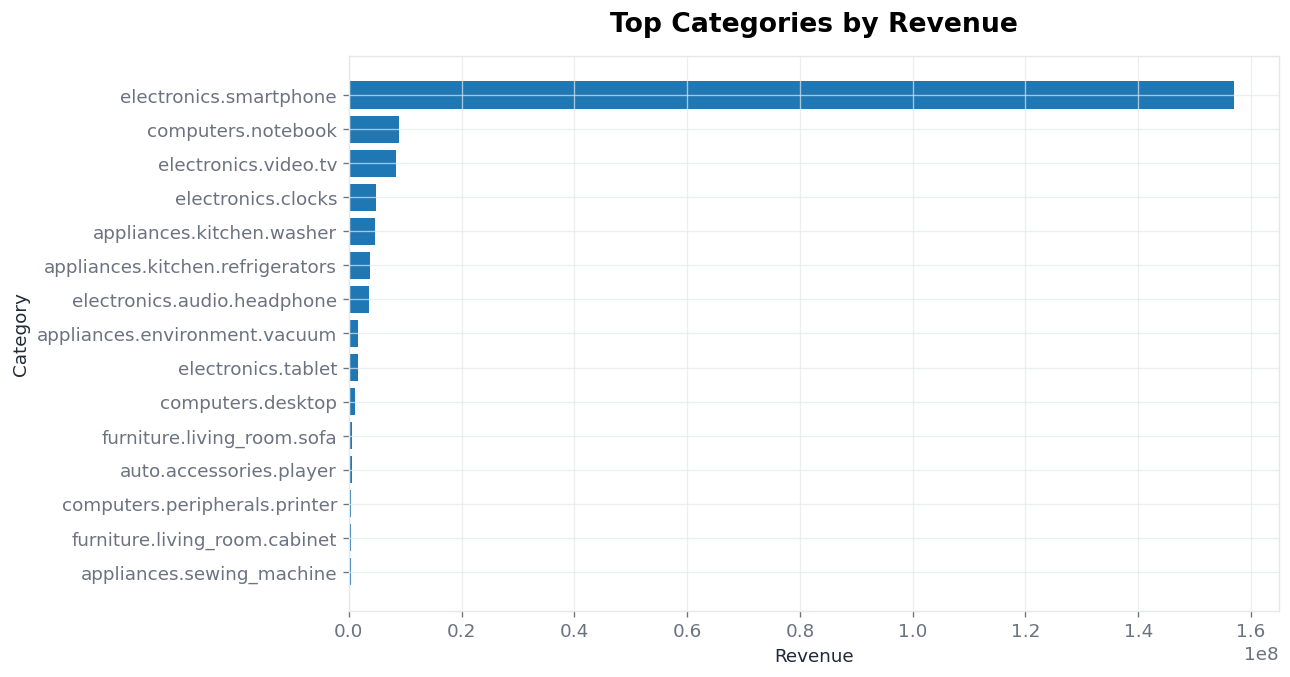

In [30]:
plt.figure(figsize=(10, 6))

plot_df = top_category.sort_values("revenue")

plt.barh(
    plot_df["category_code"],
    plot_df["revenue"]
)

plt.title("Top Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Category")

plt.show()

### 3.2.2. Brand Analysis

So sánh performance giữa các brand dựa trên traffic, purchase và revenue.


In [31]:
# ============================================================
# 3.2.2 BRAND ANALYSIS
# ============================================================

query = f"""
SELECT
    brand,

    COUNT(*) FILTER (
        WHERE event_type = 'view'
    ) AS views,

    COUNT(*) FILTER (
        WHERE event_type = 'purchase'
    ) AS purchases,

    SUM(
        CASE
            WHEN event_type = 'purchase'
            THEN price
            ELSE 0
        END
    ) AS revenue

FROM read_parquet('{parquet_path}')

WHERE brand IS NOT NULL

GROUP BY brand
"""

brand = con.execute(query).df()

brand["conversion_rate"] = (
    brand["purchases"] /
    brand["views"]
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [32]:
top_brand = (
    brand
    .sort_values("revenue", ascending=False)
    .head(15)
)

top_brand

,brand,views,purchases,revenue,conversion_rate
1700,apple,3770597,142873,1.112093e+08,0.037891
4,samsung,4806630,172896,4.640753e+07,0.035970
1709,xiaomi,2922650,56616,9.194033e+06,0.019371
1703,huawei,1045572,23501,4.883422e+06,0.022477
14,acer,411871,6882,3.576720e+06,0.016709
1719,lg,540131,8727,3.387888e+06,0.016157
15,lucente,644283,11578,3.124113e+06,0.017970
16,sony,439855,6729,2.478197e+06,0.015298
26,oppo,451449,10891,2.412960e+06,0.024125
1,lenovo,330608,4578,1.752639e+06,0.013847


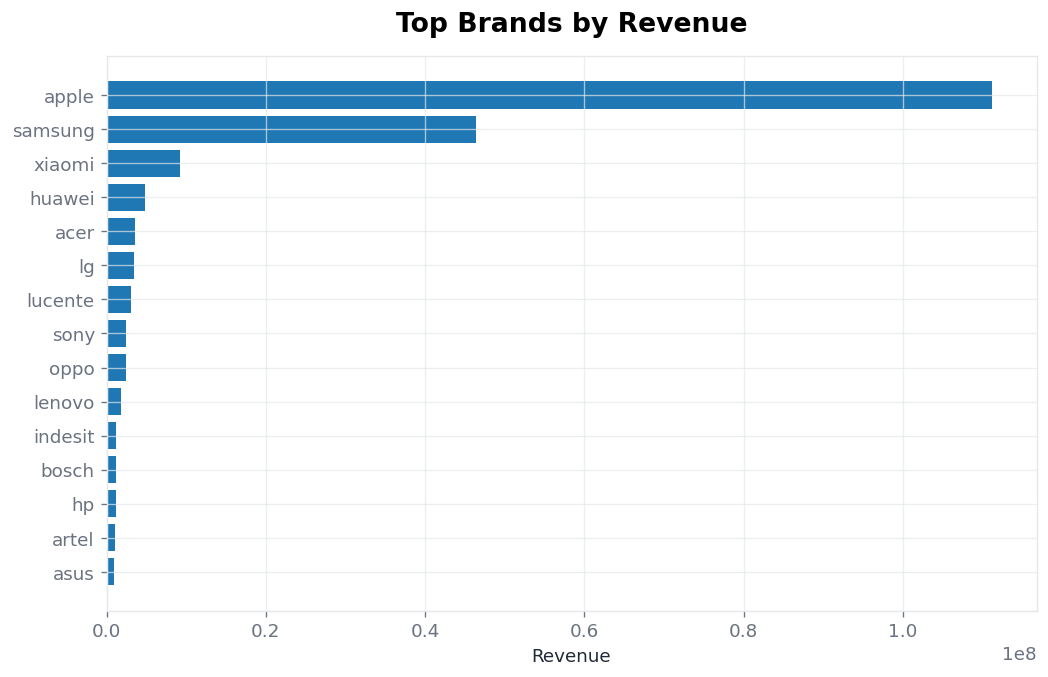

In [33]:
# Hình Top Brands by Revenue
plt.figure(figsize=(10, 6))

plot_df = top_brand.sort_values("revenue")

plt.barh(
    plot_df["brand"],
    plot_df["revenue"]
)

plt.title("Top Brands by Revenue")
plt.xlabel("Revenue")

plt.show()

In [34]:
# Top 3 Best Selling Products from Top 3 Brands
query = f"""
WITH top_3_brands AS (
    SELECT
        brand,
        SUM(price) AS revenue
    FROM read_parquet('{parquet_path}')
    WHERE event_type = 'purchase'
      AND brand IS NOT NULL
    GROUP BY brand
    ORDER BY revenue DESC
    LIMIT 3
),

product_sales AS (
    SELECT
        brand,
        product_id,
        COUNT(*) AS purchases,
        SUM(price) AS revenue
    FROM read_parquet('{parquet_path}')
    WHERE event_type = 'purchase'
      AND brand IN (SELECT brand FROM top_3_brands)
    GROUP BY brand, product_id
),

ranked AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY brand
            ORDER BY purchases DESC
        ) AS product_rank
    FROM product_sales
)

SELECT
    brand,
    product_rank,
    product_id,
    purchases,
    revenue
FROM ranked
WHERE product_rank <= 3
ORDER BY brand, product_rank
"""

top_3_products = con.execute(query).df()

top_3_products

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,brand,product_rank,product_id,purchases,revenue
0,apple,1,1005115,12543,12406807.35
1,apple,2,4804056,12381,1990026.68
2,apple,3,1002544,10549,4855702.39
3,samsung,1,1004856,28944,3798956.42
4,samsung,2,1004767,21806,5430723.43
5,samsung,3,1004833,12697,2184501.96
6,xiaomi,1,5100816,7273,208635.80
7,xiaomi,2,1004741,5276,1004221.94
8,xiaomi,3,1004739,4243,813739.20


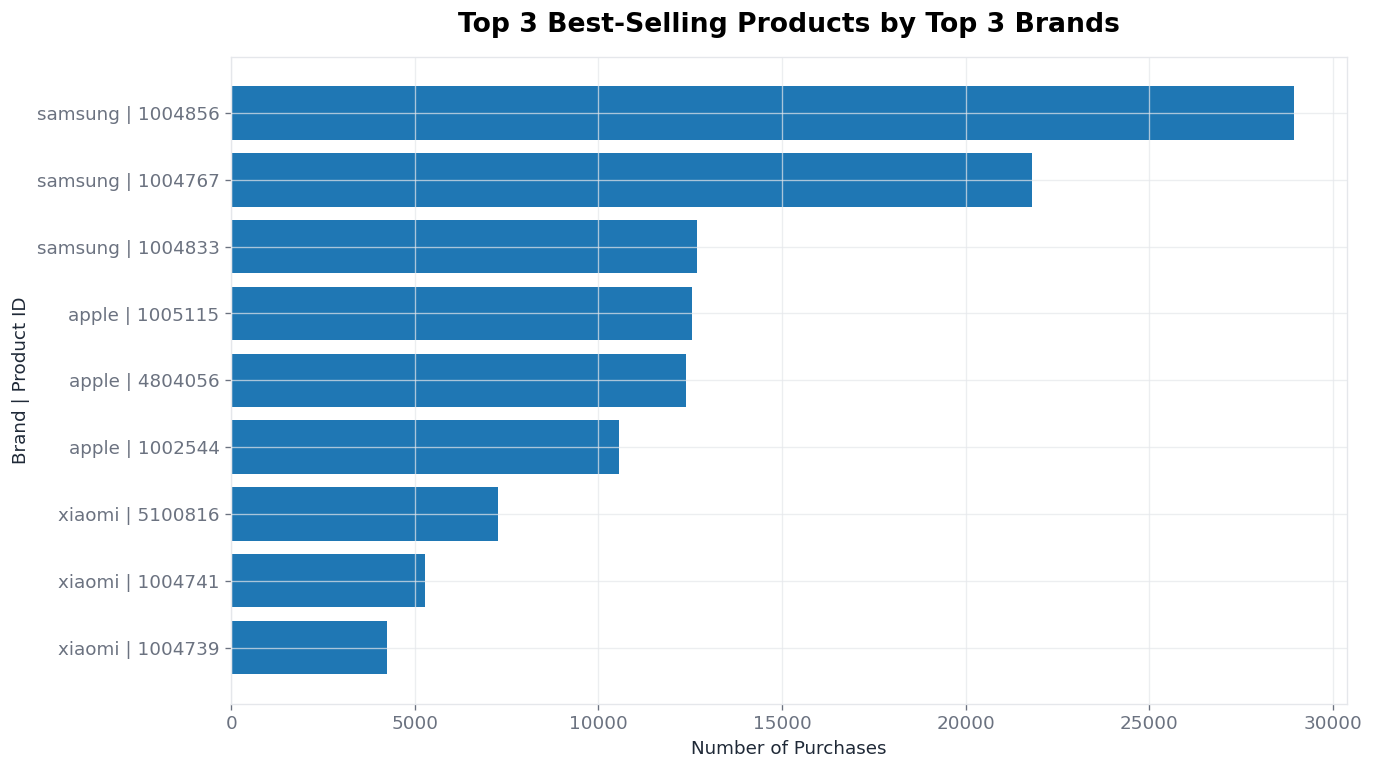

In [35]:
# Hình Top 3 Products from Top 3 Brands
plt.figure(figsize=(12, 7))

plot_df = top_3_products.copy()

plot_df["label"] = (
    plot_df["brand"].astype(str)
    + " | "
    + plot_df["product_id"].astype(str)
)

plot_df = plot_df.sort_values("purchases")

plt.barh(
    plot_df["label"],
    plot_df["purchases"]
)

plt.title("Top 3 Best-Selling Products by Top 3 Brands")
plt.xlabel("Number of Purchases")
plt.ylabel("Brand | Product ID")

plt.show()

### 3.2.3. Product Analysis

Tập trung vào mối quan hệ **Views × Conversion × Revenue** để nhận diện star products và các sản phẩm chưa khai thác hết traffic.


In [36]:
# ============================================================
# 3.2.3 PRODUCT ANALYSIS
# ============================================================

query = f"""
SELECT
    product_id,

    MAX(category_code) AS category_code,
    MAX(brand) AS brand,

    COUNT(*) FILTER (
        WHERE event_type = 'view'
    ) AS views,

    COUNT(*) FILTER (
        WHERE event_type = 'purchase'
    ) AS purchases,

    SUM(
        CASE
            WHEN event_type = 'purchase'
            THEN price
            ELSE 0
        END
    ) AS revenue

FROM read_parquet('{parquet_path}')

GROUP BY product_id
"""

product = con.execute(query).df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [37]:
product["conversion_rate"] = (
    product["purchases"] /
    product["views"]
)

In [38]:
# Revenue, Conversion_rate
product.sort_values(
    "purchases",
    ascending=False
).head(20)

,product_id,category_code,brand,views,purchases,revenue,conversion_rate
36,1004856,electronics.smartphone,samsung,419287,28944,3798956.42,0.069031
24,1004767,electronics.smartphone,samsung,378777,21806,5430723.43,0.057569
128,1004833,electronics.smartphone,samsung,203018,12697,2184501.96,0.062541
39,1005115,electronics.smartphone,apple,327715,12543,12406807.35,0.038274
159,4804056,electronics.audio.headphone,apple,179092,12381,1990026.68,0.069132
34,1004870,electronics.smartphone,samsung,190435,10615,3027098.05,0.055741
18454,1002544,electronics.smartphone,apple,179249,10549,4855702.39,0.058851
56,1004249,electronics.smartphone,apple,207422,9090,6730112.92,0.043824
18468,1004836,electronics.smartphone,samsung,143985,7691,1761450.64,0.053415
18458,1005105,electronics.smartphone,apple,197930,7293,10239248.68,0.036846


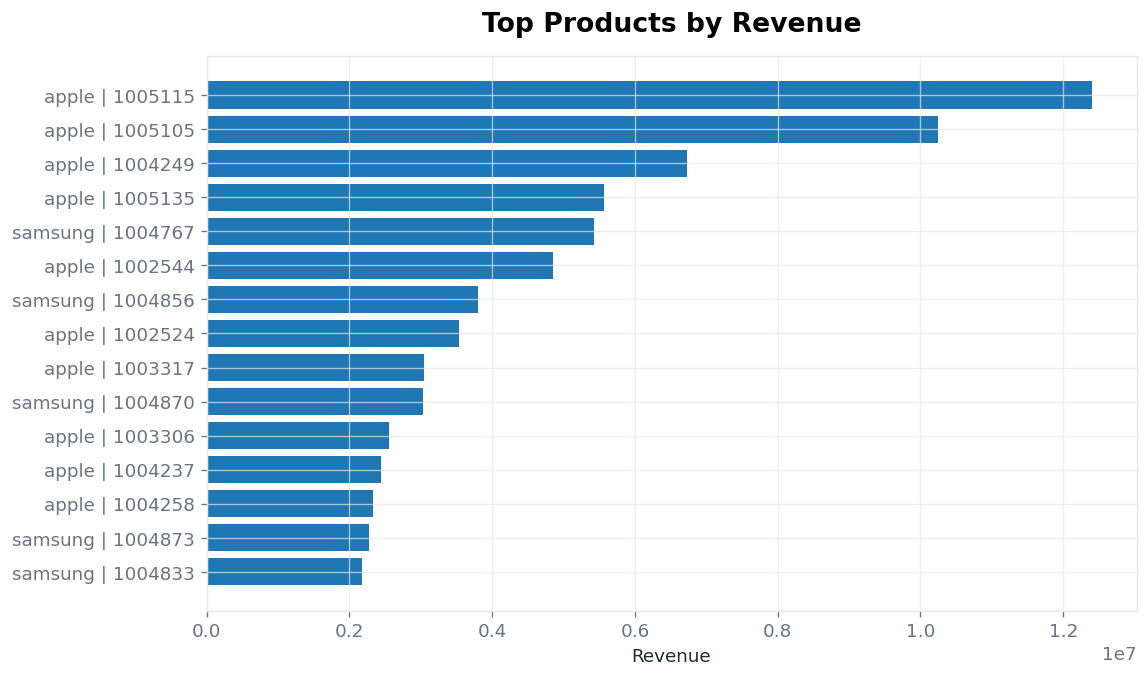

In [39]:
top_revenue = product.copy()

top_revenue["label"] = (
    top_revenue["brand"].fillna("Unknown").astype(str)
    + " | "
    + top_revenue["product_id"].astype(str)
)

top_revenue = (
    top_revenue
    .sort_values("revenue", ascending=False)
    .head(15)
    .sort_values("revenue")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_revenue["label"],
    top_revenue["revenue"]
)

plt.title("Top Products by Revenue")
plt.xlabel("Revenue")

plt.show()

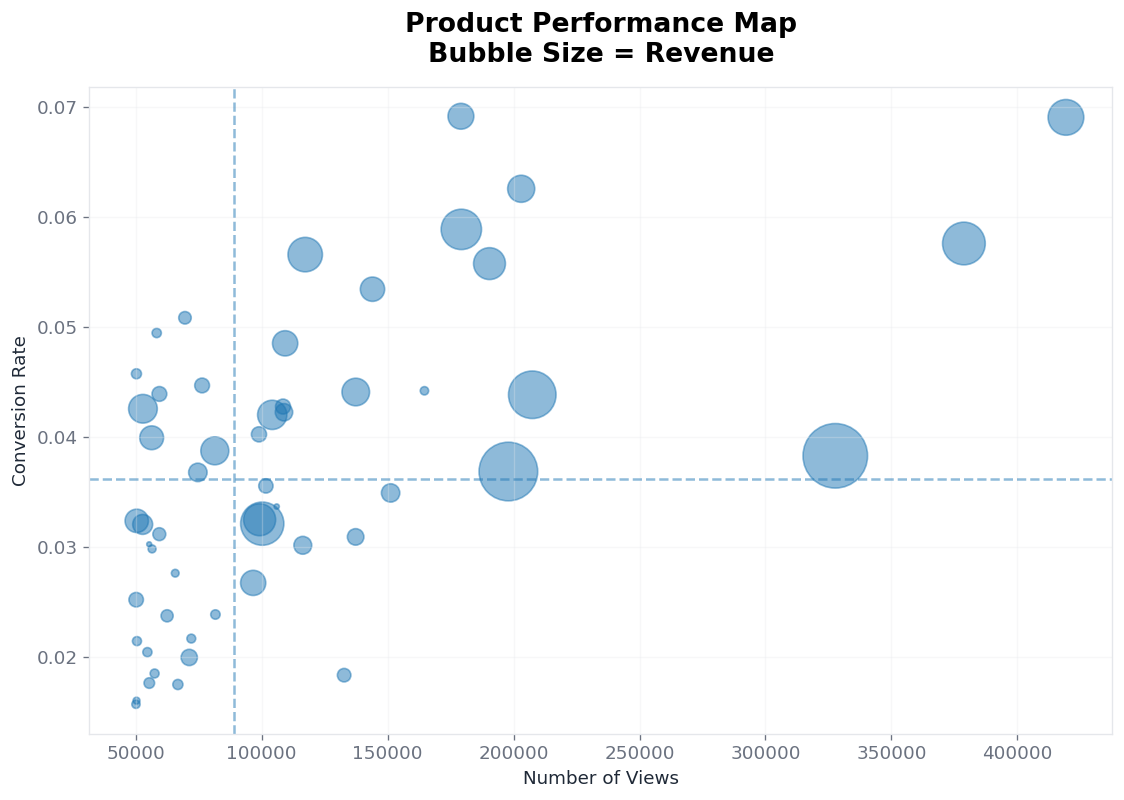

In [40]:
# ============================================================
# PRODUCT PERFORMANCE MAP
# Views × Conversion × Revenue
# ============================================================

plot_df = product[
    product["views"] >= 50000
].copy()

plt.figure(figsize=(11, 7))

plt.scatter(
    plot_df["views"],
    plot_df["conversion_rate"],

    # Bubble size thể hiện Revenue
    s=plot_df["revenue"] /
      plot_df["revenue"].max() * 1500,

    alpha=0.5
)

# Median lines
plt.axvline(plot_df["views"].median(), linestyle="--", alpha=0.5)
plt.axhline(plot_df["conversion_rate"].median(), linestyle="--", alpha=0.5)

plt.xlabel("Number of Views")
plt.ylabel("Conversion Rate")

plt.title(
    "Product Performance Map\n"
    "Bubble Size = Revenue"
)

plt.grid(alpha=0.3)

plt.show()

In [41]:
views_median = plot_df["views"].median()
conversion_median = plot_df["conversion_rate"].median()

plot_df["product_segment"] = np.select(
    [
        (plot_df["views"] >= views_median) &
        (plot_df["conversion_rate"] >= conversion_median),

        (plot_df["views"] >= views_median) &
        (plot_df["conversion_rate"] < conversion_median),

        (plot_df["views"] < views_median) &
        (plot_df["conversion_rate"] >= conversion_median),

        (plot_df["views"] < views_median) &
        (plot_df["conversion_rate"] < conversion_median)
    ],
    [
        "Star Products",
        "Traffic Opportunities",
        "Hidden Gems",
        "Low Priority"
    ],
    default="Other"
)

In [42]:
# ============================================================
# TOP PRODUCTS IN EACH SEGMENT
# ============================================================

top_products_by_segment = (
    plot_df[
        [
            "product_segment",
            "brand",
            "product_id",
            "category_code",
            "views",
            "conversion_rate",
            "revenue"
        ]
    ]
    .sort_values(
        ["product_segment", "revenue"],
        ascending=[True, False]
    )
    .groupby("product_segment")
    .head(5)
)

top_products_by_segment

,product_segment,brand,product_id,category_code,views,conversion_rate,revenue
18434,Hidden Gems,apple,1004237,electronics.smartphone,52856,0.042550,2449741.88
47,Hidden Gems,apple,1004258,electronics.smartphone,81387,0.038729,2332809.71
18568,Hidden Gems,apple,1004246,electronics.smartphone,56322,0.039913,1688139.70
18615,Hidden Gems,samsung,1801690,electronics.video.tv,74659,0.036767,1014501.39
18725,Hidden Gems,samsung,1004768,electronics.smartphone,59389,0.043897,650166.71
254,Low Priority,apple,1005104,electronics.smartphone,50397,0.032363,1624921.54
496,Low Priority,apple,1003310,electronics.smartphone,52746,0.032040,1183156.32
18731,Low Priority,samsung,1005014,electronics.smartphone,71234,0.019948,789324.18
302,Low Priority,samsung,1801881,electronics.video.tv,50164,0.025197,626580.08
296,Low Priority,huawei,1004781,electronics.smartphone,59353,0.031153,496134.96


### Key Insights & Recommendations

**Key Insights**

* High views + high conversion ở một số product cho thấy đây là nhóm **Star Products**, vừa thu hút traffic vừa chuyển đổi tốt.
* **Hidden Gems** có tiềm năng trở thành "Next Star Products".
* Một vài product có views rất cao nhưng conversion chỉ trung bình → có traffic lớn nhưng chưa khai thác hết tiềm năng doanh thu là **Traffic Opportunities**.
* Nhiều product tập trung ở vùng low views + low conversion → đóng góp hạn chế là **Low Priority**.
* Bubble lớn tập trung ở nhóm views cao cho thấy revenue chủ yếu đến từ một số ít sản phẩm chủ lực.

**Recommendations**

* Ưu tiên inventory và marketing cho **Star Products**.
* Với **Traffic Opportunities**, kiểm tra price, promotion và product page để cải thiện conversion.
* Tăng exposure cho các sản phẩm **Hidden Gems**.
* Giảm ưu tiên marketing cho nhóm **Low Priority**.


## 3.3. Funnel bị thất thoát nhiều nhất ở bước nào?

**Business Question:** Người dùng rời khỏi funnel nhiều nhất ở đâu? Purchase có nhất thiết phải đi qua Cart không?


### 3.3.1. Event-level Analysis

Phân tích event-level để nhìn toàn bộ volume của từng bước trong hành trình View → Cart → Purchase.


In [43]:
# ============================================================
# 3. FUNNEL ANALYSIS
# ============================================================

query = f"""
SELECT
    event_type,
    COUNT(*) AS events

FROM read_parquet('{parquet_path}')

WHERE event_type IN (
    'view',
    'cart',
    'purchase'
)

GROUP BY event_type
"""

funnel = con.execute(query).df()

funnel

,event_type,events
0,view,40779399
1,purchase,742849
2,cart,926516


### 3.3.2. Session-level Analysis

Chuyển sang session-level để đo tỷ lệ session có view, cart và purchase, từ đó xác định bottleneck thực sự của funnel.


In [44]:
query = f"""
SELECT

    COUNT(*) AS total_sessions,

    SUM(has_view) AS view_sessions,

    SUM(has_cart) AS cart_sessions,

    SUM(has_purchase) AS purchase_sessions

FROM (

    SELECT
        user_session,

        MAX(
            CASE WHEN event_type = 'view'
            THEN 1 ELSE 0 END
        ) AS has_view,

        MAX(
            CASE WHEN event_type = 'cart'
            THEN 1 ELSE 0 END
        ) AS has_cart,

        MAX(
            CASE WHEN event_type = 'purchase'
            THEN 1 ELSE 0 END
        ) AS has_purchase

    FROM read_parquet('{parquet_path}')

    WHERE user_session IS NOT NULL

    GROUP BY user_session
)
"""

session_funnel = con.execute(query).df()

session_funnel

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_sessions,view_sessions,cart_sessions,purchase_sessions
0,9244421,9242653.0,573097.0,629560.0


In [45]:
view_sessions = session_funnel.loc[0, "view_sessions"]
cart_sessions = session_funnel.loc[0, "cart_sessions"]
purchase_sessions = session_funnel.loc[0, "purchase_sessions"]

view_to_cart = (
    cart_sessions / view_sessions
)

cart_to_purchase = (
    purchase_sessions / cart_sessions
)

print(
    f"View → Cart      : {view_to_cart:.2%}"
)

print(
    f"Cart → Purchase  : {cart_to_purchase:.2%}"
)

print(
    f"View drop-off    : {1-view_to_cart:.2%}"
)

print(
    f"Cart drop-off    : {1-cart_to_purchase:.2%}"
)

View → Cart      : 6.20%
Cart → Purchase  : 109.85%
View drop-off    : 93.80%
Cart drop-off    : -9.85%


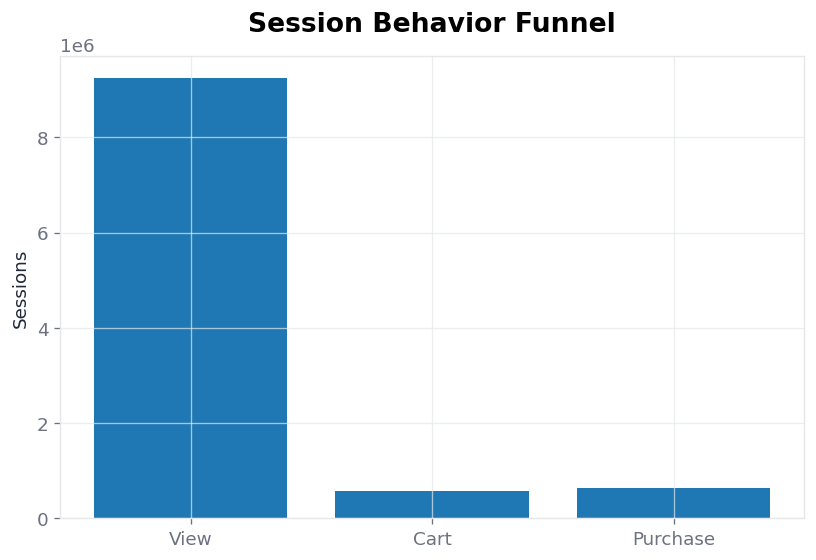

In [46]:
funnel_plot = pd.DataFrame({
    "stage": [
        "View",
        "Cart",
        "Purchase"
    ],
    "sessions": [
        view_sessions,
        cart_sessions,
        purchase_sessions
    ]
})

plt.figure(figsize=(8, 5))

plt.bar(
    funnel_plot["stage"],
    funnel_plot["sessions"]
)

plt.title("Session Behavior Funnel")
plt.ylabel("Sessions")

plt.show()

### 3.3.3. Purchase Path: Cart-assisted vs Direct Purchase

Session-level ở trên chỉ cho biết session có từng loại event, chưa chứng minh thứ tự hành vi.

Phần này phân tích theo **user–session–product** và timestamp để tách hai đường mua:

- **Cart-assisted Purchase:** View → Cart → Purchase
- **Direct / No-observed-cart Purchase:** View → Purchase mà không quan sát thấy Cart trước Purchase

> “Direct” ở đây không khẳng định người dùng bấm nút Buy Now; chỉ có nghĩa là không quan sát thấy cart event trước purchase trong cùng user–session–product.

In [47]:
# ============================================================
# 3.3.3 PURCHASE PATH
# View → Cart → Purchase vs View → Purchase
# ============================================================

query = f"""
WITH e AS (
    SELECT
        user_id,
        user_session,
        product_id,
        event_type,
        TRY_CAST(event_time AS TIMESTAMPTZ) AS ts

    FROM read_parquet('{parquet_path}')

    WHERE
        user_id IS NOT NULL
        AND user_session IS NOT NULL
        AND product_id IS NOT NULL
        AND event_type IN ('view', 'cart', 'purchase')
        AND TRY_CAST(event_time AS TIMESTAMPTZ) IS NOT NULL
),

first_view AS (
    SELECT
        user_id,
        user_session,
        product_id,
        MIN(ts) AS view_ts

    FROM e

    WHERE event_type = 'view'

    GROUP BY
        user_id,
        user_session,
        product_id
),

paths AS (
    SELECT
        v.user_id,
        v.user_session,
        v.product_id,
        v.view_ts,

        MIN(e.ts) FILTER (
            WHERE e.event_type = 'cart'
              AND e.ts > v.view_ts
        ) AS cart_ts,

        MIN(e.ts) FILTER (
            WHERE e.event_type = 'purchase'
              AND e.ts > v.view_ts
        ) AS purchase_ts

    FROM first_view v

    LEFT JOIN e
        ON  e.user_id = v.user_id
        AND e.user_session = v.user_session
        AND e.product_id = v.product_id

    GROUP BY
        v.user_id,
        v.user_session,
        v.product_id,
        v.view_ts
)

SELECT
    COUNT(*) AS viewed_pairs,

    COUNT(*) FILTER (
        WHERE purchase_ts IS NOT NULL
    ) AS purchased_pairs,

    COUNT(*) FILTER (
        WHERE purchase_ts IS NOT NULL
          AND cart_ts IS NOT NULL
          AND cart_ts < purchase_ts
    ) AS cart_assisted_purchase,

    COUNT(*) FILTER (
        WHERE purchase_ts IS NOT NULL
          AND (
              cart_ts IS NULL
              OR cart_ts >= purchase_ts
          )
    ) AS direct_purchase,

    COUNT(*) FILTER (
        WHERE purchase_ts IS NULL
    ) AS no_purchase

FROM paths
"""

purchase_path = con.execute(query).df()

purchase_path

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,viewed_pairs,purchased_pairs,cart_assisted_purchase,direct_purchase,no_purchase
0,27783988,688130,298166,389964,27095858


In [48]:
# ============================================================
# PURCHASE PATH KPIs
# ============================================================

r = purchase_path.iloc[0]

viewed = int(r["viewed_pairs"])
purchased = int(r["purchased_pairs"])
cart_assisted = int(r["cart_assisted_purchase"])
direct = int(r["direct_purchase"])

view_to_purchase_rate = (
    purchased / viewed if viewed else 0
)

cart_assisted_share = (
    cart_assisted / purchased if purchased else 0
)

direct_purchase_share = (
    direct / purchased if purchased else 0
)

purchase_path_kpi = pd.DataFrame({
    "Metric": [
        "View → Purchase Rate",
        "Cart-assisted Share",
        "Direct / No-observed-cart Share"
    ],
    "Rate": [
        view_to_purchase_rate,
        cart_assisted_share,
        direct_purchase_share
    ]
})

purchase_path_kpi["Rate"] = purchase_path_kpi["Rate"].map(
    lambda x: f"{x:.2%}"
)

display(purchase_path_kpi)

print(f"Viewed session-product pairs: {viewed:,}")
print(f"Purchased after view:         {purchased:,}")
print(f"Cart-assisted purchases:      {cart_assisted:,}")
print(f"Direct / no-cart purchases:   {direct:,}")

,Metric,Rate
0,View → Purchase Rate,2.48%
1,Cart-assisted Share,43.33%
2,Direct / No-observed-cart Share,56.67%


Viewed session-product pairs: 27,783,988
Purchased after view:         688,130
Cart-assisted purchases:      298,166
Direct / no-cart purchases:   389,964


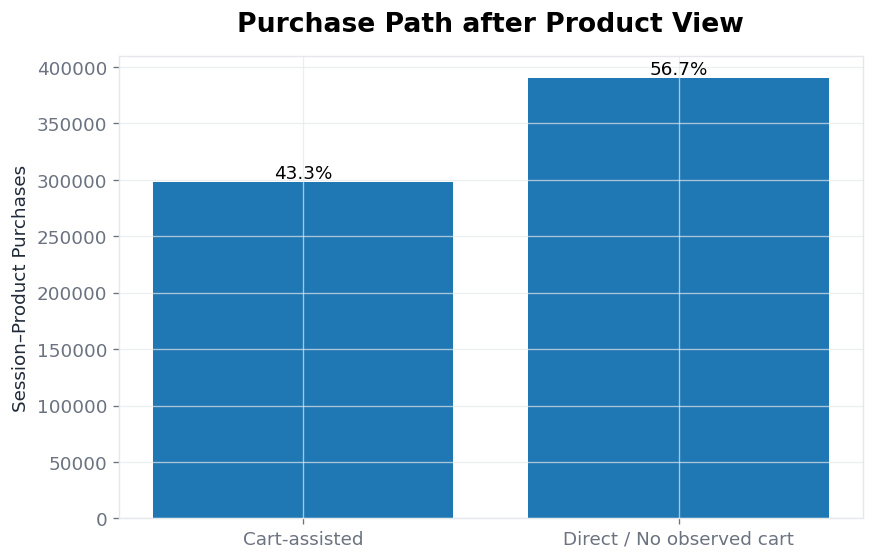

In [49]:
# Purchase path among converted session-product pairs

path_plot = pd.DataFrame({
    "Purchase Path": [
        "Cart-assisted",
        "Direct / No observed cart"
    ],
    "Purchases": [
        cart_assisted,
        direct
    ]
})

plt.figure(figsize=(8, 5))

bars = plt.bar(
    path_plot["Purchase Path"],
    path_plot["Purchases"]
)

plt.title("Purchase Path after Product View")
plt.ylabel("Session–Product Purchases")

for bar, value in zip(bars, path_plot["Purchases"]):
    share = value / purchased if purchased else 0

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{share:.1%}",
        ha="center",
        va="bottom"
    )

plt.show()

### Key Insights & Recommendations

* **View → Cart là điểm rơi lớn**: trong các session có view, chỉ 6.2% có add-to-cart → cần kiểm tra product relevance, pricing, product page/ UX, promotion, recommendation...
* Purchase > Cart cho thấy một phần người dùng có thể đi từ View trực tiếp tới Purchase, không nhất thiết phải qua Cart.

Phân tích theo đúng **user–session–product và thứ tự timestamp** tách purchase thành:

1. **Cart-assisted:** có Cart sau View và trước Purchase.
2. **Direct / No-observed-cart:** có Purchase sau View nhưng không quan sát thấy Cart trước Purchase.

Do đó, **View → Purchase Rate** phản ánh conversion tổng thể tốt hơn, trong khi **Cart → Purchase** chỉ mô tả nhánh có sử dụng cart.

**Recommendation:** Tối ưu đoạn **product discovery → purchase decision**, thay vì chỉ tập trung vào checkout.

The biggest opportunity is before checkout: turning product views into purchase intent.


## 3.4. Price có ảnh hưởng đến Conversion không?

**Business Question:** Conversion thay đổi thế nào theo Price? Có tồn tại price band / sweet spot hay không?


In [57]:
# ============================================================
# 3.4 PRICE vs CONVERSION
# ============================================================

query = f"""
WITH base AS (

    SELECT
        price,
        event_type,

        NTILE(10) OVER (
            ORDER BY price
        ) AS price_decile

    FROM read_parquet('{parquet_path}')

    WHERE
        price > 0
        AND event_type IN (
            'view',
            'purchase'
        )
)

SELECT

    price_decile,

    MIN(price) AS min_price,
    AVG(price) AS avg_price,
    MAX(price) AS max_price,

    COUNT(*) FILTER (
        WHERE event_type = 'view'
    ) AS views,

    COUNT(*) FILTER (
        WHERE event_type = 'purchase'
    ) AS purchases

FROM base

GROUP BY price_decile

ORDER BY price_decile
"""

price_analysis = con.execute(query).df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [58]:
price_analysis["conversion_rate"] = (
    price_analysis["purchases"] /
    price_analysis["views"]
)

price_analysis

,price_decile,min_price,avg_price,max_price,views,purchases,conversion_rate
0,1,0.77,17.891187,30.86,4085043,60330,0.014769
1,2,30.86,41.623873,51.48,4081712,63661,0.015597
2,3,51.48,65.903964,82.34,4090759,54614,0.013351
3,4,82.34,100.870283,122.21,4086129,59244,0.014499
4,5,122.21,140.985940,161.90,4049171,96202,0.023758
5,6,161.90,187.743479,221.11,4060924,84448,0.020795
6,7,221.11,252.661001,291.13,4051064,94308,0.023280
7,8,291.13,355.921209,434.72,4079354,66018,0.016183
8,9,434.72,562.767558,741.06,4066959,78413,0.019280
9,10,741.06,1171.943493,2574.07,4059761,85611,0.021088


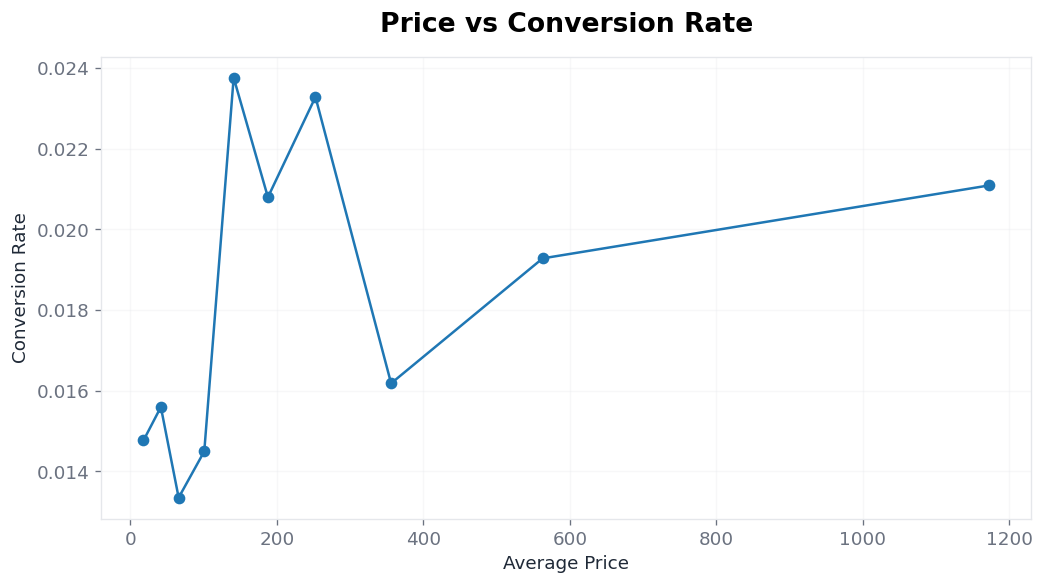

In [59]:
plt.figure(figsize=(10, 5))

plt.plot(
    price_analysis["avg_price"],
    price_analysis["conversion_rate"],
    marker="o"
)

plt.title("Price vs Conversion Rate")
plt.xlabel("Average Price")
plt.ylabel("Conversion Rate")
plt.grid(alpha=0.3)

plt.show()

In [60]:
# ============================================================
# DRILL-DOWN: PRICE × CONVERSION
# ============================================================

product_price = con.execute(f"""
    SELECT
        product_id,
        AVG(price) AS avg_price
    FROM read_parquet('{parquet_path}')
    GROUP BY product_id
""").df()

plot_df = product.merge(
    product_price,
    on="product_id",
    how="left"
)

plot_df = plot_df[
    plot_df["views"] >= 50000
].copy()

# Chia sản phẩm thành 10 Price Bands
plot_df["price_band"] = pd.qcut(
    plot_df["avg_price"],
    q=10,
    duplicates="drop"
)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [61]:
# Top 5 products có conversion cao nhất trong từng Price Band
top_products_by_price_band = (
    plot_df
    .sort_values(
        ["price_band", "conversion_rate"],
        ascending=[True, False]
    )
    .groupby("price_band", observed=True)
    .head(5)
)

top_products_by_price_band[
    [
        "price_band",
        "brand",
        "product_id",
        "category_code",
        "avg_price",
        "conversion_rate",
        "views",
        "revenue"
    ]
]

,price_band,brand,product_id,category_code,avg_price,conversion_rate,views,revenue
101,"(22.884, 117.176]",samsung,1004209,electronics.smartphone,88.952541,0.049435,58319,256534.77
18494,"(22.884, 117.176]",xiaomi,5100816,None,28.679963,0.044184,164608,208635.80
18461,"(22.884, 117.176]",xiaomi,4804295,electronics.audio.headphone,22.884587,0.033664,105958,81669.17
18549,"(22.884, 117.176]",cordiant,12703015,None,43.094844,0.030233,55336,72171.88
18823,"(22.884, 117.176]",huawei,1004903,electronics.smartphone,111.419681,0.029815,56482,187673.76
36,"(117.176, 147.434]",samsung,1004856,electronics.smartphone,131.236442,0.069031,419287,3798956.42
108,"(117.176, 147.434]",samsung,1004858,electronics.smartphone,131.724528,0.050817,69543,465454.72
18739,"(117.176, 147.434]",samsung,1004857,electronics.smartphone,130.606877,0.045729,50274,300276.93
18509,"(117.176, 147.434]",samsung,1005100,electronics.smartphone,145.004868,0.042750,108469,670291.57
19011,"(117.176, 147.434]",xiaomi,1004777,electronics.smartphone,135.814807,0.023852,81629,264001.96


In [62]:
top_products_by_price_band = (
    plot_df[
        plot_df["views"] >= 50000
    ]
    .sort_values(
        ["price_band", "conversion_rate"],
        ascending=[True, False]
    )
    .groupby("price_band", observed=True)
    .head(5)
)

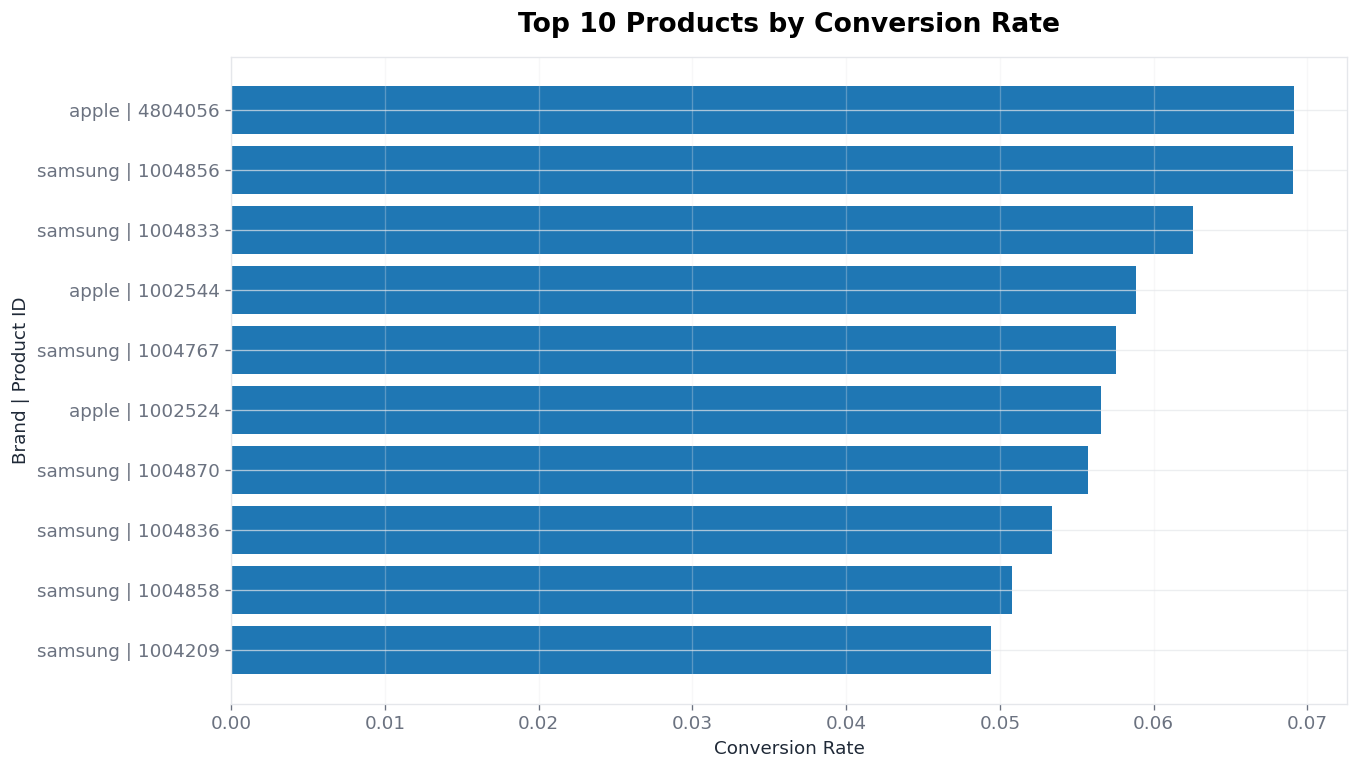

,brand,product_id,category_code,avg_price,conversion_rate,views,revenue
159,apple,4804056,electronics.audio.headphone,160.732219,0.069132,179092,1990026.68
36,samsung,1004856,electronics.smartphone,131.236442,0.069031,419287,3798956.42
128,samsung,1004833,electronics.smartphone,172.026671,0.062541,203018,2184501.96
18454,apple,1002544,electronics.smartphone,460.300738,0.058851,179249,4855702.39
24,samsung,1004767,electronics.smartphone,248.984556,0.057569,378777,5430723.43
134,apple,1002524,electronics.smartphone,533.047632,0.056560,117273,3538299.12
34,samsung,1004870,electronics.smartphone,285.057549,0.055741,190435,3027098.05
18468,samsung,1004836,electronics.smartphone,229.134499,0.053415,143985,1761450.64
108,samsung,1004858,electronics.smartphone,131.724528,0.050817,69543,465454.72
101,samsung,1004209,electronics.smartphone,88.952541,0.049435,58319,256534.77


In [63]:
# ============================================================
# TOP 10 PRODUCTS BY CONVERSION RATE
# ============================================================

top_10_conversion = (
    plot_df
    .sort_values("conversion_rate", ascending=False)
    .head(10)
    .copy()
)

top_10_conversion["label"] = (
    top_10_conversion["brand"].fillna("Unknown").astype(str)
    + " | "
    + top_10_conversion["product_id"].astype(str)
)

# Plot
plot_chart = top_10_conversion.sort_values("conversion_rate")

plt.figure(figsize=(12, 7))

plt.barh(
    plot_chart["label"],
    plot_chart["conversion_rate"]
)

plt.xlabel("Conversion Rate")
plt.ylabel("Brand | Product ID")

plt.title("Top 10 Products by Conversion Rate")

plt.grid(axis="x", alpha=0.3)

plt.show()

# Bảng chi tiết
top_10_conversion[
    [
        "brand",
        "product_id",
        "category_code",
        "avg_price",
        "conversion_rate",
        "views",
        "revenue"
    ]
]

### Key Insights

* Conversion thấp nhất với sản phẩm giá < 100 → cần kiểm tra chất lượng sản phẩm, positioning hoặc demand fit.
* Giá trung bình có conversion tốt nhất khoảng 100-250 → có thể là một price **sweet spot** (correlation).
* Conversion giảm mạnh khi price tăng từ 250 lên 350 → có dấu hiệu price sensitivity.

* Một số sản phẩm high-price vẫn có conversion cao ở nhóm 600+ → có thể phản ánh premium positioning, strong intent, brand effect.


## 3.5. Customer Value: Ai có giá trị cao hoặc nguy cơ không quay lại?

**Business Question:** Nhóm khách hàng nào đáng ưu tiên retention, reactivation và upsell?


### 3.5.1. Customer RFM (Recency | Frequency | Monetary)

Dùng RFM để định lượng mức độ gần đây, tần suất và giá trị mua hàng của từng customer.


In [64]:
# ============================================================
# 3.5. CUSTOMER VALUE / RFM
# ============================================================

query = f"""
WITH purchase AS (

    SELECT
        user_id,
        CAST(event_time AS TIMESTAMP) AS event_time,
        user_session,
        price

    FROM read_parquet('{parquet_path}')

    WHERE event_type = 'purchase'
),

snapshot AS (

    SELECT
        MAX(event_time) AS snapshot_date
    FROM purchase
)

SELECT

    user_id,

    DATE_DIFF(
        'day',
        MAX(event_time),
        MAX(snapshot_date)
    ) AS recency,

    COUNT(
        DISTINCT user_session
    ) AS frequency,

    SUM(price) AS monetary,

    COUNT(*) AS total_items

FROM purchase

CROSS JOIN snapshot

GROUP BY user_id
"""

customer_rfm = con.execute(query).df()

customer_rfm.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,user_id,recency,frequency,monetary,total_items
0,512831600,2,7,1313.45,7
1,513500315,2,7,2926.55,17
2,549527166,23,2,2828.64,2
3,518717490,29,1,18.02,1
4,546309572,17,6,1641.94,9


### 3.5.2. Customer Segmentation

Phân nhóm customer dựa trên Frequency, Monetary và Recency để hỗ trợ CRM strategy.


In [65]:
# High value threshold
freq_cut = customer_rfm["frequency"].quantile(0.75)
money_cut = customer_rfm["monetary"].quantile(0.75)

# High recency = lâu chưa quay lại
recency_cut = customer_rfm["recency"].quantile(0.75)

In [66]:
customer_rfm["segment"] = "Core"

customer_rfm.loc[
    (
        customer_rfm["frequency"] >= freq_cut
    )
    &
    (
        customer_rfm["monetary"] >= money_cut
    ),
    "segment"
] = "High Value"

customer_rfm.loc[
    (
        customer_rfm["recency"] >= recency_cut
    )
    &
    (
        customer_rfm["monetary"] >= money_cut
    ),
    "segment"
] = "At Risk"

In [67]:
# Mô tả segment
customer_rfm["segment"].value_counts()

,count
segment,
Core,280517
High Value,48500
At Risk,18101


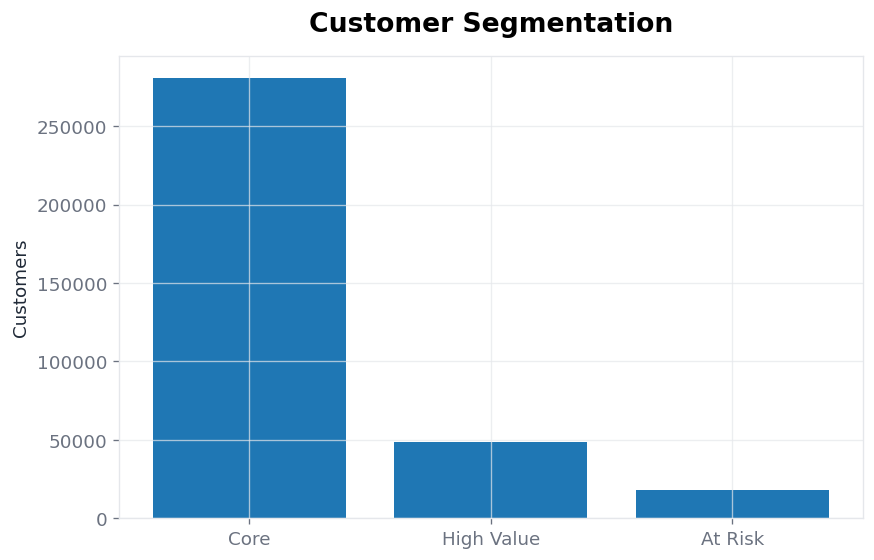

In [68]:
segment_count = (
    customer_rfm["segment"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

plt.bar(
    segment_count.index,
    segment_count.values
)

plt.title("Customer Segmentation")
plt.ylabel("Customers")

plt.show()

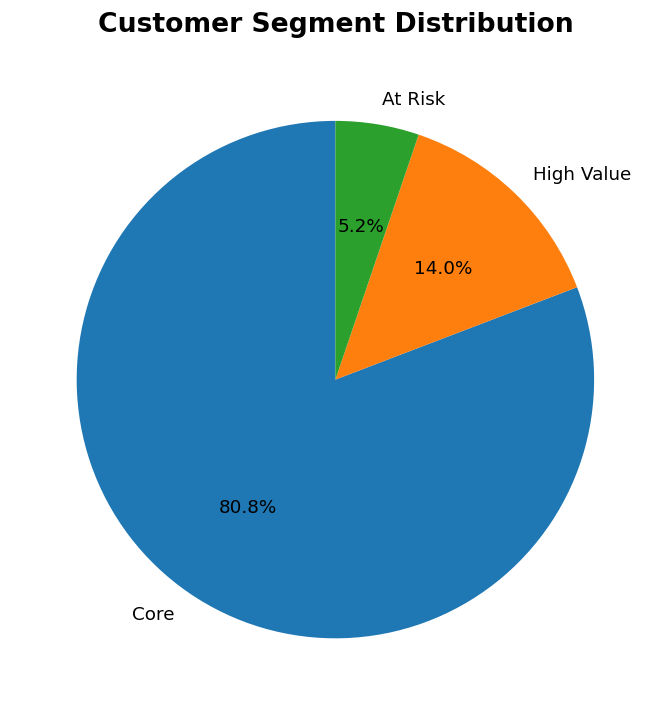

In [69]:
# Customer Segment Share

segment_counts = {
    "Core": 280517,
    "High Value": 48500,
    "At Risk": 18101
}

plt.figure(figsize=(7, 7))

plt.pie(
    segment_counts.values(),
    labels=segment_counts.keys(),
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Segment Distribution")

plt.show()

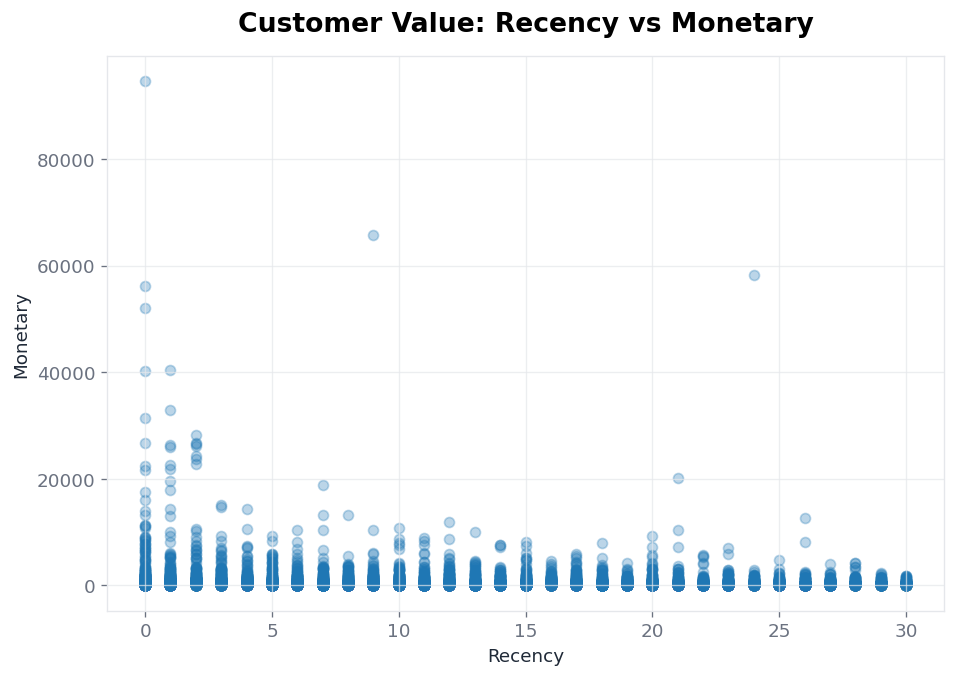

In [70]:
sample_rfm = customer_rfm.sample(
    min(10000, len(customer_rfm)),
    random_state=42
)

plt.figure(figsize=(9, 6))

plt.scatter(
    sample_rfm["recency"],
    sample_rfm["monetary"],
    alpha=0.3
)

plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.title("Customer Value: Recency vs Monetary")

plt.show()

###**Key Insights**

Core (~280K): Largest segment → biggest growth opportunity → upsell, cross-sell, category expansion và personalized recommendations.

High Value (~48.5K): Smaller but high-spending → prioritize retention, VIP benefits, early access, personalized recommendations và cross-sell.

At Risk (~18K): High-value customers showing inactivity → prioritize reactivation → personalized reminder, relevant product recommendations và limited-time offers.

## 3.6. Session nào có khả năng chuyển thành Purchase?

**Business Question:** Purchase session có behavioral signature khác non-purchase session như thế nào?


### 3.6.1. Session-level Dataset by DuckDB

Tạo dataset ở session-level bằng DuckDB để phục vụ so sánh behavior hồi cứu. Phần 3.7 dùng dataset user-day độc lập để dự báo D+1; các đặc trưng toàn session này không dùng làm đầu vào model.


In [71]:
# ============================================================
# 6. SESSION PURCHASE PROPENSITY
# ============================================================
# [Nặng]
query = f"""
SELECT

    user_session,

    MAX(user_id) AS user_id,

    COUNT(*) AS total_events,

    COUNT(*) FILTER (
        WHERE event_type = 'view'
    ) AS views,

    COUNT(*) FILTER (
        WHERE event_type = 'cart'
    ) AS carts,

    COUNT(
        DISTINCT product_id
    ) AS unique_products,

    COUNT(
        DISTINCT category_id
    ) AS unique_categories,

    AVG(price) AS avg_price,

    MAX(price) AS max_price,

    MIN(event_time::TIMESTAMP) AS session_start,

    MAX(event_time::TIMESTAMP) AS session_end,

    DATE_DIFF(
        'second',
        MIN(event_time::TIMESTAMP),
        MAX(event_time::TIMESTAMP)
    ) / 60.0 AS session_minutes,

    MAX(
        CASE
            WHEN event_type = 'purchase'
            THEN 1
            ELSE 0
        END
    ) AS purchase

FROM read_parquet('{parquet_path}')

WHERE user_session IS NOT NULL

GROUP BY user_session
"""

session_df = con.execute(query).df()

session_df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,user_session,user_id,total_events,views,carts,unique_products,unique_categories,avg_price,max_price,session_start,session_end,session_minutes,purchase
0,643790b0-0665-43cf-b886-0e068d1a80a5,513742013,14,10,0,5,1,330.871429,360.34,2019-10-01 17:24:32,2019-10-01 17:30:08,5.600000,1
1,c4ae9751-0dc7-4008-b683-b284900f163d,555727759,1,1,0,1,1,154.270000,154.27,2019-10-01 17:28:09,2019-10-01 17:28:09,0.000000,0
2,9dfc200b-9a41-47e8-b8fa-6ef6450ece27,515651609,5,5,0,5,3,38.336000,84.92,2019-10-01 17:29:10,2019-10-01 17:43:37,14.450000,0
3,84a2a219-f3a8-45c0-861a-905c29b84a5b,552176783,1,1,0,1,1,71.300000,71.30,2019-10-01 17:33:17,2019-10-01 17:33:17,0.000000,0
4,423856c1-b2fe-4f5c-b8ef-4c304772899d,555729667,10,10,0,6,2,67.973000,115.81,2019-10-01 17:33:58,2019-10-01 17:39:51,5.883333,0


In [72]:
session_df.shape

(9244421, 13)

### 3.6.2. Converted vs Non-converted Session

So sánh interaction, product exploration và purchase behavior giữa hai nhóm session.


In [73]:
session_compare = (
    session_df
    .groupby("purchase")
    [
        [
            "total_events",
            "views",
            "carts",
            "unique_products",
            "unique_categories",
            "avg_price",
            "session_minutes"
        ]
    ]
    .mean()
)

session_compare

,total_events,views,carts,unique_products,unique_categories,avg_price,session_minutes
purchase,,,,,,,
0,4.376932,4.327258,0.049674,3.015829,1.353852,314.091770,17.831374
1,7.532402,5.560503,0.791950,2.867069,1.288903,306.982348,10.979014


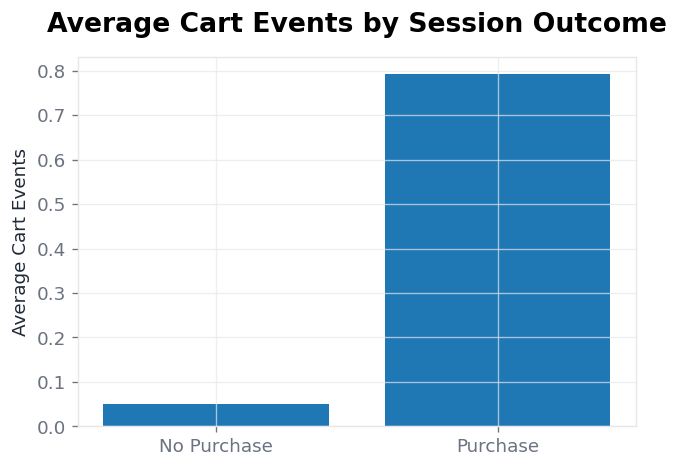

In [74]:
plot_df = (
    session_df
    .groupby("purchase")["carts"]
    .mean()
)

plt.figure(figsize=(6, 4))

plt.bar(
    ["No Purchase", "Purchase"],
    plot_df.values
)

plt.title("Average Cart Events by Session Outcome")
plt.ylabel("Average Cart Events")

plt.show()

### 3.6.3. Session Duration

Kiểm tra liệu thời lượng session và mức độ engagement có liên quan đến purchase hay không.


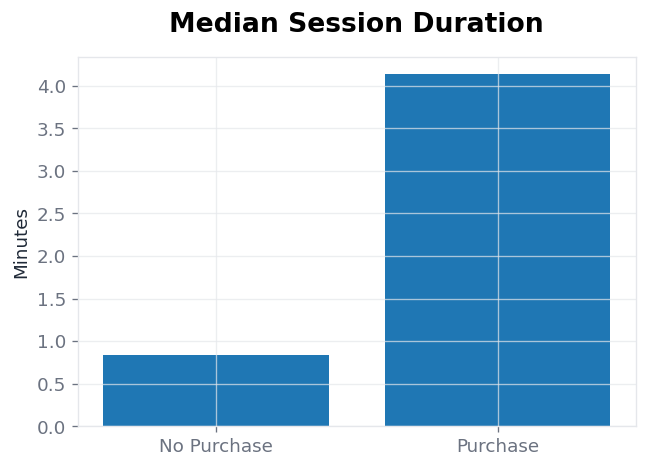

In [75]:
plot_df = (
    session_df
    .groupby("purchase")["session_minutes"]
    .median()
)

plt.figure(figsize=(6, 4))

plt.bar(
    ["No Purchase", "Purchase"],
    plot_df.values
)

plt.title("Median Session Duration")
plt.ylabel("Minutes")

plt.show()

###**Key Insights**

* Purchase session có số lần thêm vào giỏ cao gấp **~16 lần** Non-purchase session.

* Purchase session có thời gian tương tác (khám phá sản phẩm) dài hơn Non-purchase session.

👉 Hoạt động Add-to-Cart và High Engagement là **tín hiệu mạnh của ý định mua hàng.**

## 3.7. Purchase Prediction — Next-Day Purchase (D+1)

**Business question:** Tại cuối ngày D, khách đang active hôm nay có mua trong ngày D+1 không?

Phần này tích hợp phương pháp từ `ecommerce_next_day_purchase_modeling_v1_0_1.ipynb`. Đơn vị là **user × ngày**, gồm cả khách chưa từng mua.

| Thành phần | Quy ước |
|---|---|
| Population | User có ít nhất một event trong ngày D |
| Features | 24 đặc trưng; chỉ dữ liệu đến hết D, lookback tối đa 30 ngày |
| Label | Có ít nhất một purchase trong D+1; vắng mặt là 0 nếu log đủ |
| Train / Test | Ngày cũ / 7 snapshot dates có nhãn cuối cùng |
| Chọn model / tuning | Expanding-window CV trong Train, chọn mean ROC-AUC |
| Cutoff | Cost matrix trên Train OOF; khóa trước khi báo cáo Test |
| Đơn vị thời gian | UTC, score sau khi hoàn tất dữ liệu ngày D |
| Dữ liệu mẫu | Khoảng 5% user theo hash; EDA 3.1–3.6 vẫn là toàn bộ October |

User có thể xuất hiện ở nhiều ngày và cả Train/Test: đây là kiểm định theo thời gian cho active users, không phải kiểm định khách hoàn toàn mới. Mỗi fold chỉ dùng nhãn đã có đến cuối ngày validation đầu tiên, đúng thời điểm score cuối D. Kết quả CV/OOF phục vụ lựa chọn, không phải ước lượng độc lập sau tuning.

Ngày cuối file có features để demo scoring nhưng **không gán nhãn 0**, vì thiếu D+1. Lịch sử đầu October bị cắt; `days_since_purchase` chỉ tìm trong 30 ngày, không phải toàn bộ lifetime.


### 3.7.1. Setup và cấu hình

In [76]:
%pip -q install "duckdb>=1.4,<2" "pandas>=2.2,<3" "pyarrow>=18" "scikit-learn>=1.6,<2" "lightgbm>=4,<5" "joblib>=1.4" "gradio>=6,<7" "plotly>=6,<7"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 56.3 MB/s eta 0:00:00


In [77]:
from pathlib import Path
Path('next_day_purchase.py').write_text('"""Next-day purchase utilities and full-October descriptive analytics. Protocol v3."""\nfrom pathlib import Path\nimport json, math, tempfile, hashlib\nimport duckdb, joblib\nimport numpy as np\nimport pandas as pd\nfrom sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score\nPROTOCOL = \'Active user-day D → purchase on D+1; final 7 labeled dates are temporal Test; model/tuning/cutoff use Train only.\'\nMODEL_VERSION = \'next_day_purchase_v3\'\ndef lit(value): return "\'" + str(value).replace("\'", "\'\'") + "\'"\ndef source(path):\n    p=Path(path)\n    if not p.is_file(): raise FileNotFoundError(f\'Không tìm thấy dữ liệu: {p}\')\n    return f"read_parquet({lit(p)})" if p.suffix.lower()==\'.parquet\' else f"read_csv_auto({lit(p)}, sample_size=100000)"\n\n\ndef build_analytics(data_path, out_dir, memory=\'4GB\'):\n    """Full October EDA only. Does not train or require November data."""\n    out = Path(out_dir); out.mkdir(parents=True, exist_ok=True)\n    con = duckdb.connect(str(out/\'analytics.duckdb\'))\n    con.execute(f\'SET memory_limit={lit(memory)}\')\n    con.execute("SET threads=2")\n    con.execute("SET TimeZone=\'UTC\'")\n    con.execute(f\'SET temp_directory={lit(out/\'analytics_temp\')}\')\n    con.execute(f"""CREATE OR REPLACE VIEW oct AS SELECT\n        CAST(event_time AS TIMESTAMPTZ) ts, CAST(event_type AS VARCHAR) event_type,\n        CAST(user_id AS VARCHAR) user_id, CAST(user_session AS VARCHAR) user_session,\n        CAST(product_id AS VARCHAR) product_id, CAST(category_id AS VARCHAR) category_id,\n        COALESCE(CAST(category_code AS VARCHAR),\'Unknown\') category_code,\n        COALESCE(CAST(brand AS VARCHAR),\'Unknown\') brand, TRY_CAST(price AS DOUBLE) price\n        FROM {source(data_path)}""")\n    bounds=con.execute(\'SELECT min(ts),max(ts) FROM oct\').fetchone()\n    if str(bounds[0])[:7]!=\'2019-10\' or str(bounds[1])[:7]!=\'2019-10\':\n        con.close(); raise ValueError(\'EDA in this project expects October 2019 data.\')\n    con.execute(\'\'\'CREATE OR REPLACE TABLE overview AS SELECT count(*) events,\n        count(DISTINCT user_id) users, count(DISTINCT user_session) sessions,\n        count(DISTINCT user_session) FILTER(WHERE event_type=\'purchase\') purchase_sessions,\n        count(*) FILTER(WHERE event_type=\'purchase\') purchase_events,\n        sum(price) FILTER(WHERE event_type=\'purchase\') purchase_value FROM oct\'\'\')\n    con.execute(\'\'\'CREATE OR REPLACE TABLE daily AS SELECT CAST(ts AS DATE) AS day,\n        count(*) events, count(*) FILTER(WHERE event_type=\'view\') AS views,\n        count(*) FILTER(WHERE event_type=\'cart\') carts,\n        count(*) FILTER(WHERE event_type=\'purchase\') purchases,\n        coalesce(sum(price) FILTER(WHERE event_type=\'purchase\'),0) purchase_value\n        FROM oct GROUP BY day ORDER BY day\'\'\')\n    con.execute(\'\'\'CREATE OR REPLACE TABLE products AS SELECT product_id,\n        arg_max(category_id,ts) category_id, arg_max(category_code,ts) category_code,\n        arg_max(brand,ts) brand, count(*) FILTER(WHERE event_type=\'view\') AS views,\n        count(*) FILTER(WHERE event_type=\'cart\') carts,\n        count(*) FILTER(WHERE event_type=\'purchase\') purchases,\n        coalesce(sum(price) FILTER(WHERE event_type=\'purchase\'),0) purchase_value\n        FROM oct WHERE product_id IS NOT NULL GROUP BY product_id\'\'\')\n    # One unit = (user, session, product). Strict time order, including repeated events.\n    # Last purchase proves existence after the earliest valid cart; min purchase would lose valid paths.\n    con.execute(\'\'\'CREATE OR REPLACE TEMP TABLE first_view AS SELECT user_id,user_session,product_id,\n        min(ts) FILTER(WHERE event_type=\'view\') v,\n        max(ts) FILTER(WHERE event_type=\'purchase\') last_p\n        FROM oct WHERE user_id IS NOT NULL AND user_session IS NOT NULL AND product_id IS NOT NULL\n        GROUP BY user_id,user_session,product_id\'\'\')\n    con.execute(\'\'\'CREATE OR REPLACE TABLE funnel_products AS WITH valid_cart AS (\n        SELECT f.user_id,f.user_session,f.product_id,f.v,f.last_p,\n        min(e.ts) FILTER(WHERE e.event_type=\'cart\' AND e.ts>f.v) c\n        FROM first_view f LEFT JOIN oct e USING(user_id,user_session,product_id)\n        GROUP BY f.user_id,f.user_session,f.product_id,f.v,f.last_p)\n        SELECT product_id, count(*) FILTER(WHERE v IS NOT NULL) viewed,\n        count(*) FILTER(WHERE c IS NOT NULL) cart_after_view,\n        count(*) FILTER(WHERE c IS NOT NULL AND last_p>c) purchase_after_cart\n        FROM valid_cart GROUP BY product_id\'\'\')\n    con.execute(\'\'\'CREATE OR REPLACE TABLE favorites AS WITH a AS (\n        SELECT user_id,category_id,sum(CASE event_type WHEN \'view\' THEN 1 WHEN \'cart\' THEN 3 WHEN \'purchase\' THEN 5 ELSE 0 END) interest\n        FROM oct WHERE user_id IS NOT NULL AND category_id IS NOT NULL GROUP BY user_id,category_id)\n        SELECT user_id,category_id,interest FROM a QUALIFY row_number() OVER(PARTITION BY user_id ORDER BY interest DESC,category_id)=1\'\'\')\n    con.execute(\'\'\'CREATE OR REPLACE TABLE recommendations AS WITH ranked AS (\n        SELECT *,row_number() OVER(PARTITION BY category_id ORDER BY purchases DESC,product_id) rank\n        FROM products WHERE purchases>0 AND category_id IS NOT NULL)\n        SELECT * FROM ranked WHERE rank<=5\'\'\')\n\n    c=con.execute("""SELECT user_id,\n        date_diff(\'day\', max(ts), (SELECT max(ts) FROM oct WHERE event_type=\'purchase\')) recency,\n        count(DISTINCT user_session) frequency, sum(price) monetary, count(*) total_items\n        FROM oct WHERE event_type=\'purchase\' AND user_id IS NOT NULL GROUP BY user_id""").df()\n    fq=c.frequency.quantile(.75); mq=c.monetary.quantile(.75); rq=c.recency.quantile(.75)\n    c[\'segment\']=\'Core\'\n    c.loc[(c.frequency>=fq)&(c.monetary>=mq),\'segment\']=\'High Value\'\n    c.loc[(c.recency>=rq)&(c.monetary>=mq),\'segment\']=\'At Risk\'\n    con.register(\'rfm_frame\',c)\n    con.execute(\'CREATE OR REPLACE TABLE rfm AS SELECT * FROM rfm_frame\')\n    con.unregister(\'rfm_frame\')\n    con.execute(\'DROP VIEW oct\')\n    con.close()\n    return out/\'analytics.duckdb\'\n\ndef population_stability_index(expected, actual, bins=10, eps=1e-6):\n    expected = np.asarray(expected, dtype=float)\n    actual = np.asarray(actual, dtype=float)\n    edges = np.unique(np.quantile(expected, np.linspace(0, 1, bins + 1)))\n    if len(edges) < 3:\n        return np.nan, pd.DataFrame()\n    edges[0], edges[-1] = -np.inf, np.inf\n    exp_bin = pd.cut(expected, bins=edges, include_lowest=True, duplicates=\'drop\')\n    act_bin = pd.cut(actual, bins=edges, include_lowest=True, duplicates=\'drop\')\n    categories = exp_bin.categories\n    exp_pct = pd.Series(exp_bin).value_counts(normalize=True, sort=False).reindex(categories, fill_value=0)\n    act_pct = pd.Series(act_bin).value_counts(normalize=True, sort=False).reindex(categories, fill_value=0)\n    exp_pct = exp_pct.clip(lower=eps)\n    act_pct = act_pct.clip(lower=eps)\n    psi_component = (act_pct - exp_pct) * np.log(act_pct / exp_pct)\n    detail = pd.DataFrame({\n        \'score_bin\': categories.astype(str),\n        \'train_pct\': exp_pct.values,\n        \'test_pct\': act_pct.values,\n        \'psi_component\': psi_component.values\n    })\n    return float(psi_component.sum()), detail\n\n\ndef cutoff_table(y_true, score, value_tp, cost_fp, cost_fn, thresholds=None):\n    if thresholds is None:\n        thresholds = np.unique(np.r_[0.0, np.linspace(0.01, 0.99, 99), np.quantile(score, np.linspace(0.01, 0.99, 99)), np.nextafter(1.0, 2.0)])\n    rows = []\n    for threshold in thresholds:\n        pred = (score >= threshold).astype(int)\n        tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()\n        rows.append({\n            \'threshold\': float(threshold),\n            \'TN\': int(tn), \'FP\': int(fp), \'FN\': int(fn), \'TP\': int(tp),\n            \'precision\': precision_score(y_true, pred, zero_division=0),\n            \'recall\': recall_score(y_true, pred, zero_division=0),\n            \'f1\': f1_score(y_true, pred, zero_division=0),\n            \'contact_rate\': pred.mean(),\n            \'net_value\': tp * value_tp - fp * cost_fp - fn * cost_fn\n        })\n    return pd.DataFrame(rows).sort_values(\'threshold\').reset_index(drop=True)\n\ndef ranking(y,p, fraction=.1):\n    y=np.asarray(y); p=np.asarray(p); k=max(1,math.ceil(len(y)*fraction))\n    # Stable sorting resolves ties using the pre-sorted customer order.\n    idx=np.argsort(-p,kind=\'stable\')[:k]; precision=float(y[idx].mean()); base=float(y.mean())\n    return {\'Top_fraction\':fraction,\'Selected\':k,\'Precision_at_top\':precision,\n            \'Recall_at_top\':float(y[idx].sum()/max(y.sum(),1)), \'Lift_at_top\':precision/base if base else np.nan}\n\n', encoding="utf-8")


8564

In [78]:
import warnings
from pathlib import Path
import tempfile
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, precision_score, recall_score,
    f1_score, roc_curve, average_precision_score
)
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')




from next_day_purchase import population_stability_index, cutoff_table, build_analytics
# Giữ nguyên parquet_path và con của EDA để 3.8–3.11 tiếp tục chạy.
DATA_PATH = Path(parquet_path)
assert DATA_PATH.is_file(), f'Sửa parquet_path tại phần 2: {DATA_PATH}'
USER_SAMPLE_MOD = 20  # 20 ≈ 5%; 10 ≈ 10%; 1 = full users
LOOKBACK_DAYS = 30   # Feature names use _30d; keep this definition fixed.
TEST_DAYS = 7
CV_FOLDS = 3
SEED = 42
MEMORY_LIMIT = '4GB'
ROOT = Path('/content/ecommerce_purchase_v3')
ROOT.mkdir(parents=True, exist_ok=True)
DRIVE_OUTPUT_DIR = DATA_PATH.parent / 'next_day_purchase_v3'
assert isinstance(USER_SAMPLE_MOD, int) and USER_SAMPLE_MOD >= 1
print('Data:', DATA_PATH, '| Sample: 1/', USER_SAMPLE_MOD)
print('Persistent artifacts:', DRIVE_OUTPUT_DIR)


Data: /content/drive/MyDrive/CoderSchool Exercises /Final Project | Kaggle Data/LeVietDang | Final Project/FinalProject/data/2019-Oct.parquet | Sample: 1/ 20
Persistent artifacts: /content/drive/MyDrive/CoderSchool Exercises /Final Project | Kaggle Data/LeVietDang | Final Project/FinalProject/data/next_day_purchase_v3


### 3.7.2. Dữ liệu, features và label D+1


DuckDB aggregate trực tiếp trên parquet, giúp giảm RAM so với load toàn bộ 1.47 GB vào pandas. Sample theo hash của `user_id` để một user được giữ đầy đủ trên toàn bộ tháng.

In [79]:
model_con = duckdb.connect(str(ROOT / 'modeling.duckdb'))
model_con.execute("PRAGMA threads=4")
model_con.execute(f"SET memory_limit='{MEMORY_LIMIT}'")
model_con.execute("SET TimeZone='UTC'")
model_con.execute(f"SET temp_directory='{ROOT / 'duckdb_temp'}'")

model_parquet_path = str(DATA_PATH).replace("'", "''")
sample_filter = (
    'WHERE user_id IS NOT NULL' if USER_SAMPLE_MOD == 1
    else f'WHERE user_id IS NOT NULL AND hash(user_id) % {USER_SAMPLE_MOD} = 0'
)

model_con.execute(f'''
CREATE OR REPLACE TABLE events AS
SELECT
    CAST(CAST(event_time AS TIMESTAMPTZ) AT TIME ZONE 'UTC' AS TIMESTAMP) AS event_time,
    CAST(CAST(event_time AS TIMESTAMPTZ) AT TIME ZONE 'UTC' AS DATE) AS event_date,
    CAST(event_type AS VARCHAR) AS event_type,
    CAST(product_id AS BIGINT) AS product_id,
    CAST(category_id AS BIGINT) AS category_id,
    CAST(category_code AS VARCHAR) AS category_code,
    CAST(brand AS VARCHAR) AS brand,
    CAST(price AS DOUBLE) AS price,
    CAST(user_id AS BIGINT) AS user_id,
    CAST(user_session AS VARCHAR) AS user_session
FROM read_parquet('{model_parquet_path}')
{sample_filter}
''')

audit = model_con.execute('''
SELECT
    COUNT(*) AS row_count,
    COUNT(DISTINCT user_id) AS user_count,
    COUNT(DISTINCT event_date) AS day_count,
    MIN(event_time) AS min_time,
    MAX(event_time) AS max_time,
    AVG(CAST(brand IS NULL AS INTEGER)) AS brand_missing_rate,
    AVG(CAST(category_code IS NULL AS INTEGER)) AS category_missing_rate
FROM events
''').df()
display(audit)

event_summary = model_con.execute('''
SELECT event_type, COUNT(*) AS event_count
FROM events
GROUP BY event_type
ORDER BY event_count DESC
''').df()
display(event_summary)

if int(audit.loc[0, 'day_count']) < TEST_DAYS + 7:
    raise ValueError(
        'Dữ liệu không đủ số ngày để train/test. Kiểm tra path hoặc giảm USER_SAMPLE_MOD.'
    )
# Missing whole days would create false negative labels; stop early.
covered = model_con.execute('SELECT DISTINCT event_date FROM events ORDER BY 1').df()['event_date']
expected_days = pd.date_range(covered.min(), covered.max(), freq='D')
assert len(covered)==len(expected_days), 'Missing event dates: check data/sample before labeling.'
assert pd.Timestamp(covered.min())==pd.Timestamp('2019-10-01') and pd.Timestamp(covered.max())==pd.Timestamp('2019-10-31'), 'This project expects complete October 2019.'


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,row_count,user_count,day_count,min_time,max_time,brand_missing_rate,category_missing_rate
0,2131545,151384,31,2019-10-01 00:00:23,2019-10-31 23:59:46,0.143093,0.31739


,event_type,event_count
0,view,2046689
1,cart,46866
2,purchase,37990


### Feature dictionary

**Label**

Với mỗi user active trong ngày D:

\[
y_{u,D}=\begin{cases}
1 & \text{nếu user có purchase trong ngày D+1}\\
0 & \text{nếu không có purchase trong ngày D+1}
\end{cases}
\]

Ngày cuối cùng của file bị loại vì không có ngày D+1 để quan sát label.

**24 features**

| Nhóm | Features | Vì sao cần |
|---|---|---|
| Intent ngày D | `views_1d`, `carts_1d`, `removes_1d`, `purchases_1d` | Đo mức độ quan tâm và vị trí trong funnel gần nhất |
| Breadth ngày D | `sessions_1d`, `products_1d`, `categories_1d`, `brands_1d` | Phân biệt xem tập trung với browsing rộng |
| Price/value | `avg_price_1d`, `max_price_1d`, `cart_value_1d` | Đại diện mức giá quan tâm và quy mô giỏ hàng |
| Recent history | `events_7d`, `views_7d`, `carts_7d`, `purchases_7d` | Đo cường độ tương tác ngắn hạn |
| Customer history | `active_days_30d`, `purchases_30d`, `days_since_purchase` | Phân biệt new/one-day user và returning user |
| Ratios/signals | `cart_view_ratio_1d`, `open_cart_signal`, `recent_activity_share` | Chuyển count thành tín hiệu intent dễ so sánh |
| Calendar | `day_of_week`, `is_weekend` | Hành vi mua có thể khác theo ngày |

`days_since_purchase` có thể null nếu user chưa từng mua; pipeline sẽ impute bằng median của Train. Không fill trước khi split để tránh leakage.
`events_30d` cũng thuộc bộ 24 features. `open_cart_signal` chỉ là cart > 0 và purchase = 0 trong D, không xác nhận giỏ còn hàng; cart_value là tổng giá tại cart events, có thể lặp.


In [80]:
# Bảng user-day: một dòng cho mỗi user trong mỗi ngày.
model_con.execute('''
CREATE OR REPLACE TABLE user_day AS
SELECT
    event_date,
    user_id,
    COUNT(*) AS event_count,
    COUNT(*) FILTER (WHERE event_type = 'view') AS view_count,
    COUNT(*) FILTER (WHERE event_type = 'cart') AS cart_count,
    COUNT(*) FILTER (WHERE event_type = 'remove_from_cart') AS remove_count,
    COUNT(*) FILTER (WHERE event_type = 'purchase') AS purchase_count,
    COUNT(DISTINCT user_session) AS session_count,
    COUNT(DISTINCT product_id) AS product_count,
    COUNT(DISTINCT category_id) AS category_count,
    COUNT(DISTINCT brand) AS brand_count,
    AVG(price) AS avg_price,
    MAX(price) AS max_price,
    COALESCE(SUM(price) FILTER (WHERE event_type = 'cart'), 0) AS cart_value
FROM events
WHERE user_id IS NOT NULL
GROUP BY event_date, user_id
''')

# Candidate = user active ngày D; ngày cuối có features nhưng target NULL.
# Features chỉ join các ngày <= snapshot_date.
model_con.execute(f'''
CREATE OR REPLACE TABLE model_table AS
WITH boundary AS (
    SELECT MAX(event_date) AS max_date FROM user_day
),
candidate AS (
    SELECT d.event_date AS snapshot_date, d.user_id
    FROM user_day d, boundary b
    WHERE d.event_date <= b.max_date
),
feature_base AS (
    SELECT
        c.snapshot_date,
        c.user_id,
        SUM(CASE WHEN h.event_date = c.snapshot_date THEN h.view_count ELSE 0 END) AS views_1d,
        SUM(CASE WHEN h.event_date = c.snapshot_date THEN h.cart_count ELSE 0 END) AS carts_1d,
        SUM(CASE WHEN h.event_date = c.snapshot_date THEN h.remove_count ELSE 0 END) AS removes_1d,
        SUM(CASE WHEN h.event_date = c.snapshot_date THEN h.purchase_count ELSE 0 END) AS purchases_1d,
        SUM(CASE WHEN h.event_date = c.snapshot_date THEN h.session_count ELSE 0 END) AS sessions_1d,
        SUM(CASE WHEN h.event_date = c.snapshot_date THEN h.product_count ELSE 0 END) AS products_1d,
        SUM(CASE WHEN h.event_date = c.snapshot_date THEN h.category_count ELSE 0 END) AS categories_1d,
        SUM(CASE WHEN h.event_date = c.snapshot_date THEN h.brand_count ELSE 0 END) AS brands_1d,
        MAX(CASE WHEN h.event_date = c.snapshot_date THEN h.avg_price END) AS avg_price_1d,
        MAX(CASE WHEN h.event_date = c.snapshot_date THEN h.max_price END) AS max_price_1d,
        SUM(CASE WHEN h.event_date = c.snapshot_date THEN h.cart_value ELSE 0 END) AS cart_value_1d,
        SUM(CASE WHEN h.event_date >= c.snapshot_date - INTERVAL 6 DAY THEN h.event_count ELSE 0 END) AS events_7d,
        SUM(CASE WHEN h.event_date >= c.snapshot_date - INTERVAL 6 DAY THEN h.view_count ELSE 0 END) AS views_7d,
        SUM(CASE WHEN h.event_date >= c.snapshot_date - INTERVAL 6 DAY THEN h.cart_count ELSE 0 END) AS carts_7d,
        SUM(CASE WHEN h.event_date >= c.snapshot_date - INTERVAL 6 DAY THEN h.purchase_count ELSE 0 END) AS purchases_7d,
        SUM(h.event_count) AS events_30d,
        SUM(h.purchase_count) AS purchases_30d,
        COUNT(DISTINCT h.event_date) AS active_days_30d,
        DATE_DIFF(
            'day',
            MAX(CASE WHEN h.purchase_count > 0 THEN h.event_date END),
            c.snapshot_date
        ) AS days_since_purchase
    FROM candidate c
    JOIN user_day h
      ON h.user_id = c.user_id
     AND h.event_date BETWEEN c.snapshot_date - INTERVAL {LOOKBACK_DAYS - 1} DAY
                          AND c.snapshot_date
    GROUP BY c.snapshot_date, c.user_id
),
label_base AS (
    SELECT
        event_date - INTERVAL 1 DAY AS snapshot_date,
        user_id,
        1 AS label
    FROM user_day
    WHERE purchase_count > 0
)
SELECT
    f.*,
    CASE WHEN f.snapshot_date = (SELECT max_date FROM boundary) THEN NULL ELSE COALESCE(l.label, 0) END AS target,
    f.carts_1d / (f.views_1d + 1.0) AS cart_view_ratio_1d,
    CASE WHEN f.carts_1d > 0 AND f.purchases_1d = 0 THEN 1 ELSE 0 END AS open_cart_signal,
    f.events_7d / (f.events_30d + 1.0) AS recent_activity_share,
    EXTRACT(dow FROM f.snapshot_date) AS day_of_week,
    CASE WHEN EXTRACT(dow FROM f.snapshot_date) IN (0, 6) THEN 1 ELSE 0 END AS is_weekend
FROM feature_base f
LEFT JOIN label_base l
  ON f.snapshot_date = l.snapshot_date
 AND f.user_id = l.user_id
''')

model_audit = model_con.execute('''
SELECT
    COUNT(*) AS row_count,
    COUNT(DISTINCT user_id) AS user_count,
    MIN(snapshot_date) AS min_date,
    MAX(snapshot_date) AS max_date,
    AVG(target) AS target_rate
FROM model_table
''').df()
display(model_audit)

# Kiểm tra độc lập label D+1. Mismatch phải bằng 0.
label_check = model_con.execute('''
SELECT SUM(
    m.target != CASE WHEN COALESCE(n.purchase_count, 0) > 0 THEN 1 ELSE 0 END
) AS mismatches
FROM model_table m
LEFT JOIN user_day n
  ON n.user_id = m.user_id
 AND n.event_date = m.snapshot_date + INTERVAL 1 DAY
WHERE m.target IS NOT NULL
''').df()
display(label_check)
assert int(label_check.iloc[0, 0]) == 0, 'Label D+1 chưa khớp.'
assert model_con.execute("SELECT count(*)-count(DISTINCT (user_id,snapshot_date)) FROM model_table").fetchone()[0]==0


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,row_count,user_count,min_date,max_date,target_rate
0,325049,151384,2019-10-01,2019-10-31,0.023952


,mismatches
0,0.0


### 3.7.3. Temporal split và model selection


Chỉ tạo hai tập chính:

- **Train:** toàn bộ ngày trước 7 ngày cuối.
- **Test:** 7 snapshot dates cuối.

Không random split vì production luôn dùng quá khứ để dự báo tương lai. Việc model selection và tuning dùng time-based cross-validation **bên trong Train**; Test không tham gia ra quyết định.

In [81]:
feature_df = model_con.execute('SELECT * FROM model_table ORDER BY snapshot_date, user_id').df()
feature_df['snapshot_date'] = pd.to_datetime(feature_df['snapshot_date'])
df = feature_df[feature_df.target.notna()].copy()
df['snapshot_date'] = pd.to_datetime(df['snapshot_date'])

all_dates = np.array(sorted(df['snapshot_date'].unique()))
if len(all_dates) <= TEST_DAYS + CV_FOLDS + 2:
    raise ValueError('Không đủ ngày cho Train/Test và time-based CV.')

test_start = pd.Timestamp(all_dates[-TEST_DAYS])
train = df[df['snapshot_date'] < test_start].copy().reset_index(drop=True)
test = df[df['snapshot_date'] >= test_start].copy().reset_index(drop=True)

ID_COLS = ['snapshot_date', 'user_id', 'target']
FEATURES = [c for c in df.columns if c not in ID_COLS]

X_train, y_train = train[FEATURES], train['target'].astype(int)
X_test, y_test = test[FEATURES], test['target'].astype(int)

split_report = pd.DataFrame([
    {
        'dataset': 'Train', 'rows': len(train),
        'start_date': train.snapshot_date.min(),
        'end_date': train.snapshot_date.max(),
        'target_rate': y_train.mean()
    },
    {
        'dataset': 'Test', 'rows': len(test),
        'start_date': test.snapshot_date.min(),
        'end_date': test.snapshot_date.max(),
        'target_rate': y_test.mean()
    }
])
display(split_report)

for name, y in [('Train', y_train), ('Test', y_test)]:
    assert y.nunique() == 2, f'{name} chỉ có một class; tăng sample size.'

# Expanding-window CV theo ngày, chỉ nằm trong Train.
train_dates = np.array(sorted(train['snapshot_date'].unique()))
date_blocks = np.array_split(train_dates, CV_FOLDS + 1)
time_cv = []
for fold in range(1, len(date_blocks)):
    fit_dates = np.concatenate(date_blocks[:fold])
    val_dates = date_blocks[fold]
    fit_idx = np.flatnonzero(train['snapshot_date'].isin(fit_dates).to_numpy())
    val_idx = np.flatnonzero(train['snapshot_date'].isin(val_dates).to_numpy())
    if len(fit_idx) and len(val_idx) and y_train.iloc[fit_idx].nunique() == 2 and y_train.iloc[val_idx].nunique() == 2:
        time_cv.append((fit_idx, val_idx))

if len(time_cv) < 2:
    raise ValueError('Không tạo được ít nhất 2 time folds; tăng sample hoặc số ngày.')

print('Features:', len(FEATURES))
print('Time CV folds:', len(time_cv))
assert train.snapshot_date.max() < test.snapshot_date.min()
for fit_idx, val_idx in time_cv:
    assert train.snapshot_date.iloc[fit_idx].max() < train.snapshot_date.iloc[val_idx].min()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,dataset,rows,start_date,end_date,target_rate
0,Train,244035,2019-10-01,2019-10-23,0.024828
1,Test,71050,2019-10-24,2019-10-30,0.020943


Features: 24
Time CV folds: 3


**So sánh ba thuật toán**

| Model | Vai trò | Trade-off |
|---|---|---|
| Logistic Regression | Baseline dễ giải thích | Khó học quan hệ phi tuyến |
| Random Forest | Challenger phi tuyến | Có thể nặng và kém hiệu quả hơn boosting trên tabular data lớn |
| LightGBM | Candidate chính cho tabular data | Cần tuning và kiểm soát overfitting |

`class_weight='balanced'` hoặc `scale_pos_weight` giúp model chú ý hơn đến lớp purchase hiếm. Accuracy không dùng để chọn model; tiêu chí lựa chọn là **mean ROC-AUC của time-based CV trên Train**.

In [82]:
positive = max(int(y_train.sum()), 1)
negative = len(y_train) - positive
imbalance_ratio = negative / positive

models = {
    'Logistic Regression': Pipeline([
        ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            C=1.0, max_iter=500, class_weight='balanced', random_state=SEED
        ))
    ]),
    'Random Forest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestClassifier(
            n_estimators=200, max_depth=12, min_samples_leaf=50,
            class_weight='balanced_subsample', n_jobs=-1, random_state=SEED
        ))
    ]),
    'LightGBM': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', LGBMClassifier(
            objective='binary', n_estimators=400, learning_rate=0.05,
            num_leaves=31, min_child_samples=100,
            subsample=0.8, colsample_bytree=0.8,
            reg_lambda=1.0, class_weight='balanced',
            random_state=SEED, n_jobs=-1, verbosity=-1
        ))
    ])
}

comparison_rows = []
for model_name, estimator in models.items():
    cv_auc = cross_val_score(
        estimator, X_train, y_train,
        cv=time_cv, scoring='roc_auc', n_jobs=1
    )
    estimator.fit(X_train, y_train)
    train_score = estimator.predict_proba(X_train)[:, 1]
    comparison_rows.append({
        'model': model_name,
        'cv_auc_mean': cv_auc.mean(),
        'cv_auc_std': cv_auc.std(),
        'train_auc': roc_auc_score(y_train, train_score)
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    'cv_auc_mean', ascending=False
).reset_index(drop=True)
display(comparison_df)

selected_model_name = comparison_df.loc[0, 'model']
print('Model selected using Train CV:', selected_model_name)
print('Test is evaluated only for the locked champion; no Test results in this selection table.')

,model,cv_auc_mean,cv_auc_std,train_auc
0,Random Forest,0.813289,0.021131,0.866087
1,Logistic Regression,0.806482,0.022125,0.808349
2,LightGBM,0.783053,0.032834,0.889609


Model selected using Train CV: Random Forest
Test is evaluated only for the locked champion; no Test results in this selection table.


### 3.7.4. Fine-tuning


Search space thay đổi theo model thắng ở bước trước. `RandomizedSearchCV` chỉ chạy trên các time folds thuộc Train. Sau tuning, `best_estimator_` được fit lại trên toàn bộ Train.

Để notebook chạy nhanh, v1 dùng `n_iter=8`. Khi chuyển sang full data, nên bắt đầu với cấu hình này rồi mới mở rộng search space nếu thời gian cho phép.

In [83]:
param_spaces = {
    'Logistic Regression': {
        'model__C': np.logspace(-2, 1, 20)
    },
    'Random Forest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [2, 4]
    },
    'LightGBM': {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.02, 0.05],

    }
}

tuner = RandomizedSearchCV(
    estimator=models[selected_model_name],
    param_distributions=param_spaces[selected_model_name],
    n_iter=min(8, int(np.prod([len(v) for v in param_spaces[selected_model_name].values()]))),
    scoring='roc_auc',
    cv=time_cv,
    random_state=SEED,
    n_jobs=1,
    verbose=1,
    refit=True
)
tuner.fit(X_train, y_train)

champion = tuner.best_estimator_
print('Best Train-CV AUC:', round(tuner.best_score_, 5))
print('Best parameters:')
display(pd.DataFrame({
    'parameter': list(tuner.best_params_.keys()),
    'value': list(tuner.best_params_.values())
}))

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best Train-CV AUC: 0.81534
Best parameters:


,parameter,value
0,model__n_estimators,200
1,model__max_depth,4


### 3.7.5. Chọn cutoff trên Train OOF


Không mặc định dùng cutoff 0.5. Khi target hiếm hoặc model dùng class weighting, 0.5 thường không phải operating point tối ưu.

### Cost assumptions mẫu

- `VALUE_TP`: giá trị khi target đúng một buyer.
- `COST_FP`: chi phí contact một non-buyer.
- `COST_FN`: opportunity cost khi bỏ sót buyer.

\[
Net\ Value = TP\times VALUE_{TP} - FP\times COST_{FP} - FN\times COST_{FN}
\]

Cutoff được chọn trên **out-of-fold predictions của Train**, sau đó áp dụng nguyên trạng lên Test. Hãy thay cost assumptions bằng số thực tế trước khi dùng cho business.
**Net value là utility proxy theo giả định**, không phải doanh thu/lợi nhuận tăng thêm. OOF được tạo lại với cấu hình đã chọn; tuning và cutoff dùng cùng Train nên không coi giá trị OOF tối ưu là đánh giá độc lập. Có thêm hai chính sách contact tất cả / không contact để so sánh.

In [84]:
# ----- Thay các giả định này bằng business inputs thực tế -----
VALUE_TP = 50_000
COST_FP = 2_000
COST_FN = 10_000

# Out-of-fold score trong Train để chọn cutoff mà không nhìn Test.
oof_score = np.full(len(train), np.nan)
for fit_idx, val_idx in time_cv:
    fold_model = clone(champion)
    fold_model.fit(X_train.iloc[fit_idx], y_train.iloc[fit_idx])
    oof_score[val_idx] = fold_model.predict_proba(X_train.iloc[val_idx])[:, 1]

oof_mask = ~np.isnan(oof_score)
y_cutoff = y_train.to_numpy()[oof_mask]
s_cutoff = oof_score[oof_mask]


cutoff_analysis = cutoff_table(
    y_cutoff, s_cutoff, VALUE_TP, COST_FP, COST_FN
)
best_row = cutoff_analysis.loc[cutoff_analysis['net_value'].idxmax()]
recommended_cutoff = float(best_row['threshold'])

print('Recommended cutoff from Train OOF:', round(recommended_cutoff, 4))
display(best_row.to_frame('value'))



Recommended cutoff from Train OOF: 0.5715


,value
threshold,5.714732e-01
TN,1.496600e+05
FP,3.240500e+04
FN,1.632000e+03
TP,3.085000e+03
precision,8.692589e-02
recall,6.540174e-01
f1,1.534559e-01
contact_rate,1.900076e-01
net_value,7.312000e+07


### 3.7.6. Đánh giá Test: AUC, AP, PSI và confusion matrix


### AUC

- AUC = 0.5: gần random.
- AUC càng cao: khả năng xếp buyer cao hơn non-buyer càng tốt.
- `Train AUC - Test AUC` lớn: dấu hiệu overfitting hoặc drift.

### PSI

PSI so sánh phân phối score giữa Train và Test:

- `< 0.10`: ổn định.
- `0.10–0.25`: cần theo dõi/điều tra.
- `> 0.25`: thay đổi đáng kể.

PSI không đo accuracy. PSI thấp không đảm bảo model tốt; cần đọc cùng Test AUC và target rate.
Các mốc PSI là quy tắc tham khảo; so sánh Train in-sample với Test còn chịu ảnh hưởng overfit và lịch sử đầu tháng ngắn. Score từ class weighting chưa được hiệu chỉnh xác suất.

In [85]:
train_score = champion.predict_proba(X_train)[:, 1]
test_score = champion.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, train_score)
test_auc = roc_auc_score(y_test, test_score)
score_psi, psi_detail = population_stability_index(train_score, test_score)

def psi_status(value):
    if pd.isna(value): return 'Not available'
    if value < 0.10: return 'Stable'
    if value < 0.25: return 'Monitor'
    return 'Material shift'

performance_report = pd.DataFrame([
    {'metric': 'Train AUC', 'value': train_auc, 'interpretation': 'Development fit'},
    {'metric': 'Test AUC', 'value': test_auc, 'interpretation': 'Out-of-time performance'},
    {'metric': 'AUC gap', 'value': train_auc - test_auc, 'interpretation': 'Overfit/drift indicator'},
    {'metric': 'Score PSI', 'value': score_psi, 'interpretation': psi_status(score_psi)}
])
display(performance_report)
display(psi_detail)
print("Test Average Precision:", average_precision_score(y_test, test_score))
# Final untouched Test report at the locked cutoff.
test_pred = (test_score >= recommended_cutoff).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, test_pred, labels=[0, 1]).ravel()
test_cutoff_report = pd.DataFrame([{
    'cutoff': recommended_cutoff,
    'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
    'precision': precision_score(y_test, test_pred, zero_division=0),
    'recall': recall_score(y_test, test_pred, zero_division=0),
    'f1': f1_score(y_test, test_pred, zero_division=0),
    'contact_rate': test_pred.mean(),
    'net_value': tp * VALUE_TP - fp * COST_FP - fn * COST_FN
}])
display(test_cutoff_report)

cm = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=['Actual 0', 'Actual 1'],
    columns=['Predicted 0', 'Predicted 1']
)
display(cm)

,metric,value,interpretation
0,Train AUC,0.810221,Development fit
1,Test AUC,0.817254,Out-of-time performance
2,AUC gap,-0.007033,Overfit/drift indicator
3,Score PSI,0.033904,Stable


,score_bin,train_pct,test_pct,psi_component
0,"(-inf, 0.19]",0.105829,0.071429,0.013524
1,"(0.19, 0.217]",0.094187,0.091724,0.000065
2,"(0.217, 0.228]",0.100150,0.079226,0.004904
3,"(0.228, 0.254]",0.099834,0.086671,0.001861
4,"(0.254, 0.299]",0.100002,0.097171,0.000081
5,"(0.299, 0.408]",0.100006,0.128529,0.007157
6,"(0.408, 0.459]",0.099990,0.102266,0.000051
7,"(0.459, 0.524]",0.100002,0.118030,0.002988
8,"(0.524, 0.671]",0.099998,0.116960,0.002658
9,"(0.671, inf]",0.100002,0.107994,0.000615


Test Average Precision: 0.17276701480406526


,cutoff,TN,FP,FN,TP,precision,recall,f1,contact_rate,net_value
0,0.571473,58110,11452,554,934,0.075408,0.627688,0.13464,0.174328,18256000


,Predicted 0,Predicted 1
Actual 0,58110,11452
Actual 1,554,934


### 3.7.7. Lưu model, scores và dữ liệu dùng chung với Gradio

Chỉ cần train tại đây một lần rồi mở notebook Gradio. Folder mới `next_day_purchase_v3` chứa model bundle, 24 features, cutoff/costs, version, Train OOF, Test scores, latest-day scores và các bảng báo cáo. Không dùng cache mô hình cũ.

In [86]:
import json, joblib, shutil, platform, importlib.metadata as metadata
from next_day_purchase import MODEL_VERSION, PROTOCOL

scored_test = test[['snapshot_date', 'user_id'] + FEATURES].copy()
scored_test['purchase_probability'] = test_score  # compatibility name; uncalibrated score
scored_test['predicted_purchase'] = test_pred
scored_test['recommended_action'] = np.where(test_pred == 1, 'TARGET', 'DO NOT TARGET')
scored_test['actual_target'] = y_test.to_numpy()
scored_test = scored_test.sort_values(['purchase_probability','snapshot_date','user_id'], ascending=[False,True,True])
scored_test.to_parquet(ROOT/'scored_test.parquet', index=False)
scored_test.to_csv(ROOT/'scored_test_v1.csv', index=False)
pd.DataFrame({'target': y_cutoff, 'score': s_cutoff}).to_parquet(ROOT/'train_oof.parquet', index=False)
pd.DataFrame({'target': y_train, 'score': train_score}).to_parquet(ROOT/'train_scores.parquet', index=False)

latest = feature_df[feature_df.snapshot_date == feature_df.snapshot_date.max()].copy()
assert latest.target.isna().all(), 'Latest day must not have an observed D+1 label.'
latest = latest.drop(columns='target')
latest['purchase_probability'] = champion.predict_proba(latest[FEATURES])[:,1]
latest['predicted_purchase'] = (latest.purchase_probability >= recommended_cutoff).astype(int)
latest['recommended_action'] = np.where(latest.predicted_purchase == 1, 'TARGET', 'DO NOT TARGET')
latest.to_parquet(ROOT/'scored_latest.parquet', index=False)

bundle = {
    'model': champion, 'features': FEATURES, 'cutoff': recommended_cutoff,
    'model_name': selected_model_name, 'model_version': MODEL_VERSION,
    'feature_version': 'user_day_24_features_v1', 'timezone': 'UTC',
    'training_end_date': str(train.snapshot_date.max().date()),
    'latest_training_label_date': str((train.snapshot_date.max()+pd.Timedelta(days=1)).date()),
    'scoring_time': 'End of snapshot_date, after that day is complete',
    'lookback_days': LOOKBACK_DAYS, 'user_sample_mod': USER_SAMPLE_MOD,
    'calibration': 'Not calibrated; class-weighted propensity scores',
    'cost_assumptions': {'value_tp': VALUE_TP, 'cost_fp': COST_FP, 'cost_fn': COST_FN},
}
joblib.dump(bundle, ROOT/'next_day_purchase_model_v1.joblib')
for name, table in {
    'data_audit': audit, 'event_summary': event_summary, 'model_audit': model_audit,
    'split_report': split_report, 'model_comparison': comparison_df,
    'performance_report': performance_report, 'psi_detail': psi_detail,
    'cutoff_analysis': cutoff_analysis, 'test_cutoff_report': test_cutoff_report,
}.items():
    table.to_csv(ROOT/f'{name}.csv', index=False)
report = {k:v for k,v in bundle.items() if k!='model'}
report.update({
    'protocol': PROTOCOL, 'train_auc': float(train_auc), 'test_auc': float(test_auc),
    'cv_auc': float(tuner.best_score_), 'score_psi': float(score_psi),
    'test_ap': float(average_precision_score(y_test, test_score)),
    'test_prevalence': float(y_test.mean()), 'n_train': len(train), 'n_test': len(test),
    'n_test_users': int(test.user_id.nunique()),
    'test_start': str(test.snapshot_date.min().date()), 'test_end': str(test.snapshot_date.max().date()),
    'latest_snapshot': str(latest.snapshot_date.max().date()),
    'sample_scope': f'Hash sample: 1/{USER_SAMPLE_MOD} users, complete available histories',
    'data_path': str(DATA_PATH), 'source_size': DATA_PATH.stat().st_size,
    'best_params': tuner.best_params_,
    'packages': {p:metadata.version(p) for p in ['duckdb','pandas','scikit-learn','lightgbm','joblib','pyarrow']},
})
(ROOT/'model_report.json').write_text(json.dumps(report, indent=2, ensure_ascii=False, default=str))
# A deterministic sample of real feature rows for testing CSV batch scoring.
latest[['user_id','snapshot_date']+FEATURES].head(20).to_csv(ROOT/'batch_features_example.csv', index=False)
print('Champion:', selected_model_name)
display(performance_report)
display(test_cutoff_report)
print('Artifacts ready:', ROOT)


Champion: Random Forest


,metric,value,interpretation
0,Train AUC,0.810221,Development fit
1,Test AUC,0.817254,Out-of-time performance
2,AUC gap,-0.007033,Overfit/drift indicator
3,Score PSI,0.033904,Stable


,cutoff,TN,FP,FN,TP,precision,recall,f1,contact_rate,net_value
0,0.571473,58110,11452,554,934,0.075408,0.627688,0.13464,0.174328,18256000


Artifacts ready: /content/ecommerce_purchase_v3


In [87]:
# Persist the trained model first so an EDA cache failure does not require retraining.
model_con.close()
DRIVE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
for p in ROOT.iterdir():
    if p.is_file() and p.suffix in {'.csv','.parquet','.json','.joblib'}:
        shutil.copy2(p, DRIVE_OUTPUT_DIR/p.name)
print('Saved model and score artifacts:', DRIVE_OUTPUT_DIR)

# Full October aggregates for business tabs; model scores remain user-sampled.
BUILD_FULL_ANALYTICS = True
if BUILD_FULL_ANALYTICS:
    build_analytics(DATA_PATH, ROOT, memory=MEMORY_LIMIT)
    shutil.copy2(ROOT/'analytics.duckdb', DRIVE_OUTPUT_DIR/'analytics.duckdb')
    print('Saved full-October analytics cache.')
print('Next: open updated Gradio notebook and use this OUTPUT_DIR.')


Saved model and score artifacts: /content/drive/MyDrive/CoderSchool Exercises /Final Project | Kaggle Data/LeVietDang | Final Project/FinalProject/data/next_day_purchase_v3


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Saved full-October analytics cache.
Next: open updated Gradio notebook and use this OUTPUT_DIR.


### 3.7.8. Kết quả đã lưu trong notebook nguồn và cách kết luận

**Nguồn:** output có sẵn của `ecommerce_next_day_purchase_modeling_v1_0_1.ipynb`; chưa phải kết quả chạy lại của notebook tích hợp này.

| Chỉ tiêu | Kết quả nguồn |
|---|---:|
| Train / Test user-days | 244.035 / 71.050 |
| Train snapshot dates | 01–23/10/2019 |
| Test snapshot dates | 24–30/10/2019; labels 25–31/10 |
| Test target rate | 2,0943% |
| Champion sau tuning | Random Forest, 200 trees, max_depth=4 |
| Train-CV ROC-AUC | 0,81534 |
| Train / Test ROC-AUC | 0,81022 / 0,81725 |
| Score PSI | 0,03389 |
| Cutoff Train OOF | 0,571473 |
| Test precision / recall | 7,5408% / 62,7688% |
| Test contact rate | 17,4328% |
| TN / FP / FN / TP | 58.110 / 11.452 / 554 / 934 |
| Utility proxy tại cost minh họa | 18.256.000 đơn vị giá trị giả định |

> Mô hình xếp hạng khả năng mua ngày kế tiếp của user active. Trong kết quả nguồn, chọn 12.386/71.050 user-days bao phủ 934/1.488 positive user-days. Precision 7,54% cao khoảng 3,60 lần base rate 2,09%. Đây là **user-days**, không phải 71.050 khách duy nhất và không phải 934 người mua do campaign tạo ra.

**AUC 0,817 không có nghĩa dự đoán đúng 81,7% khách.** Score 0,57 cũng không được diễn giải là xác suất mua thực tế 57% khi chưa calibration.

Bản tích hợp giữ target, bộ features, split và search space của nguồn; bổ sung kiểm tra ngày thiếu/ID, giữ nhãn ngày cuối ở NULL, không hiển thị Test trong lúc chọn model, tính class weight LightGBM theo từng fold và xét cả cutoff contact-all/contact-none. Do đó cần chạy lại để có báo cáo chính thức; số mới từ artifacts là nguồn cho Gradio. Không tái dùng kết quả 62% của bài toán mua lại theo tháng.

**Giới hạn:** chỉ một tháng, Test 7 ngày, sample user; chưa đánh giá tháng khác, uplift hay calibration. Demo latest-day là batch hồi cứu ngày cuối October, không phải dữ liệu thời gian thực.


## 3.8. Recommendation sản phẩm cho từng khách hàng

**Recommendation flow**

User interest → Favorite Category → Top purchased products → Recommendation


### 3.8.1. User Favorite Category

Xác định category yêu thích dựa trên lịch sử tương tác / mua hàng của từng user.


In [88]:
# ============================================================
# PRODUCT RECOMMENDATION
# ============================================================

query = f"""
WITH user_category AS (

    SELECT

        user_id,
        category_id,

        SUM(
            CASE
                WHEN event_type = 'view'
                    THEN 1

                WHEN event_type = 'cart'
                    THEN 3

                WHEN event_type = 'purchase'
                    THEN 5

                ELSE 0
            END
        ) AS interest_score

    FROM read_parquet('{parquet_path}')

    GROUP BY
        user_id,
        category_id
),

ranked AS (

    SELECT
        *,

        ROW_NUMBER() OVER (
            PARTITION BY user_id
            ORDER BY interest_score DESC
        ) AS rn

    FROM user_category
)

SELECT
    user_id,
    category_id,
    interest_score

FROM ranked

WHERE rn = 1
"""

favorite_category = con.execute(query).df()

favorite_category.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,user_id,category_id,interest_score
0,519107250,2053013557024391671,11.0
1,535871217,2053013560899928785,32.0
2,512742880,2053013561092866779,47.0
3,550978835,2053013558031024687,3.0
4,519528062,2053013555631882655,6.0


### 3.8.2. Top Products in Each Category

Xác định product nổi bật trong từng category làm candidate cho recommendation.


In [89]:
query = f"""
WITH product_sales AS (

    SELECT

        category_id,
        product_id,
        MAX(brand) AS brand,

        COUNT(*) AS purchases,

        SUM(price) AS revenue

    FROM read_parquet('{parquet_path}')

    WHERE event_type = 'purchase'

    GROUP BY
        category_id,
        product_id
),

ranked AS (

    SELECT
        *,

        ROW_NUMBER() OVER (
            PARTITION BY category_id
            ORDER BY purchases DESC
        ) AS product_rank

    FROM product_sales
)

SELECT *

FROM ranked

WHERE product_rank <= 5
"""

top_products_category = con.execute(query).df()

top_products_category.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,category_id,product_id,brand,purchases,revenue,product_rank
0,2053013555631882655,1004856,samsung,28944,3798956.42,1
1,2053013555631882655,1004767,samsung,21806,5430723.43,2
2,2053013555631882655,1004833,samsung,12697,2184501.96,3
3,2053013555631882655,1005115,apple,12543,12406807.35,4
4,2053013555631882655,1004870,samsung,10615,3027098.05,5


### 3.8.3. Generate Recommendation

Kết hợp favorite category và product ranking để tạo recommendation ở user-level.


In [90]:
recommendation = (
    favorite_category
    .merge(
        top_products_category,
        on="category_id",
        how="left"
    )
)

recommendation.head(20)

,user_id,category_id,interest_score,product_id,brand,purchases,revenue,product_rank
0,519107250,2053013557024391671,11.0,15100370.0,None,323.0,83059.45,1.0
1,519107250,2053013557024391671,11.0,15100337.0,None,298.0,76630.70,2.0
2,519107250,2053013557024391671,11.0,15100009.0,None,238.0,76594.68,3.0
3,519107250,2053013557024391671,11.0,15100148.0,lider,206.0,77886.60,4.0
4,519107250,2053013557024391671,11.0,15100008.0,bts,181.0,88472.40,5.0
5,535871217,2053013560899928785,32.0,4700478.0,sho-me,411.0,58529.56,1.0
6,535871217,2053013560899928785,32.0,4700630.0,None,300.0,9261.36,2.0
7,535871217,2053013560899928785,32.0,4700589.0,xiaomi,235.0,16795.86,3.0
8,535871217,2053013560899928785,32.0,4700419.0,sho-me,133.0,19449.27,4.0
9,535871217,2053013560899928785,32.0,4700549.0,neoline,82.0,12635.94,5.0


###3.8.4. Recommendation Output

In [91]:
# ============================================================
# RECOMMENDATION OUTPUT
# ============================================================
# Mỗi user sẽ có tối đa 5 sản phẩm recommendation,
# dựa trên category yêu thích và ranking sản phẩm trong category đó.

recommendation_output = recommendation[
    [
        "user_id",
        "category_id",
        "product_id",
        "brand",
        "product_rank"
    ]
].sort_values(
    ["user_id", "product_rank"]
)

recommendation_output.head(20)

,user_id,category_id,product_id,brand,product_rank
14780899,33869381,2053013560346280633,7004492.0,belecoo,1.0
14780900,33869381,2053013560346280633,7004508.0,belecoo,2.0
14780901,33869381,2053013560346280633,7002254.0,wingoffly,3.0
14780902,33869381,2053013560346280633,7005751.0,None,4.0
14780903,33869381,2053013560346280633,7004509.0,belecoo,5.0
7302757,64078358,2053013561554240247,10600098.0,None,1.0
7302758,64078358,2053013561554240247,10600485.0,matrol,2.0
7302759,64078358,2053013561554240247,10600066.0,None,3.0
7302760,64078358,2053013561554240247,10600053.0,None,4.0
7302761,64078358,2053013561554240247,10600051.0,None,5.0


###3.8.5. Recommendation Summary

In [92]:
# Sản phẩm nào được recommendation cho nhiều user nhất
# → candidate tốt để ưu tiên recommendation exposure.
recommendation_summary = (
    recommendation_output
    .groupby("product_id")
    .agg(
        recommended_users=("user_id", "nunique"),
        brand=("brand", "first"),
        avg_rank=("product_rank", "mean")
    )
    .sort_values(
        "recommended_users",
        ascending=False
    )
)

recommendation_summary.head(10)

,recommended_users,brand,avg_rank
product_id,,,
1004767.0,1014416,samsung,2.0
1004833.0,1014416,samsung,3.0
1004856.0,1014416,samsung,1.0
1004870.0,1014416,samsung,5.0
1005115.0,1014416,apple,4.0
12703015.0,145179,cordiant,1.0
12703415.0,145179,cordiant,4.0
12703494.0,145179,cordiant,3.0
12702958.0,145179,cordiant,5.0


###**Key Insight**
Recommendation được **cá nhân hóa từ user interest, sau đó ưu tiên top-selling products trong category yêu thích.**

## 3.9. Management Matrix: Interest vs Conversion

Đặt **Views** và **Conversion** trên cùng một framework để ưu tiên nguồn lực.


In [93]:
category_plot = category[
    category["views"] >= 10000
].copy()

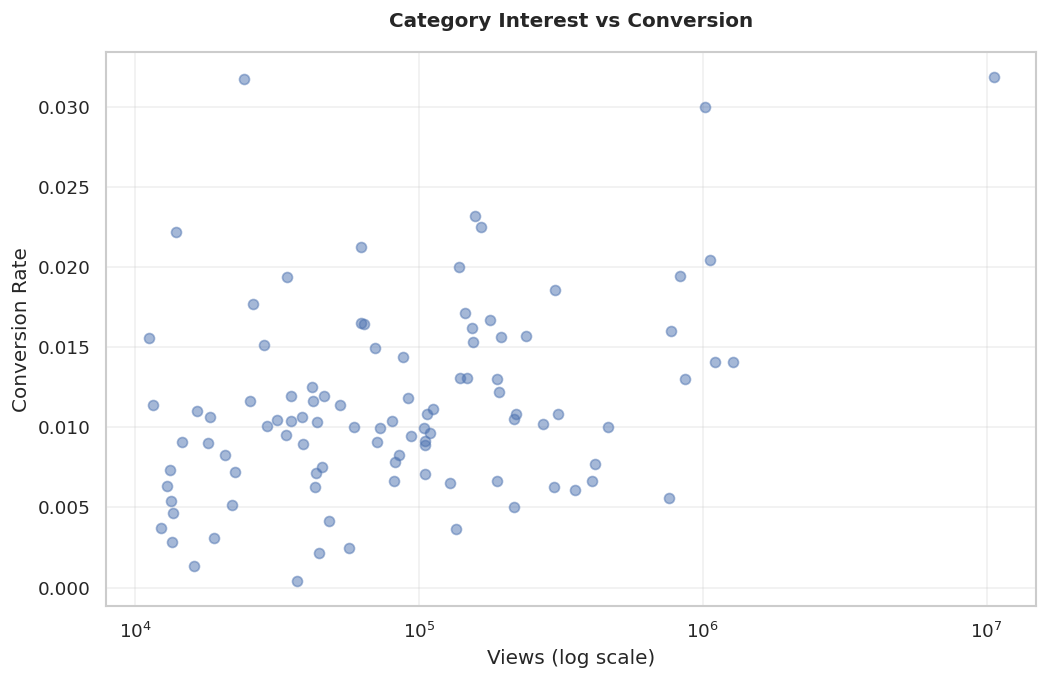

In [94]:
plt.figure(figsize=(10, 6))

plt.scatter(
    category_plot["views"],
    category_plot["view_to_purchase"],
    alpha=0.5
)

plt.xscale("log")

plt.xlabel("Views (log scale)")
plt.ylabel("Conversion Rate")
plt.title("Category Interest vs Conversion")

plt.grid(alpha=0.3)

plt.show()

###**Key Insights**
* High Views + High Conversion: Category nổi bật → ưu tiên marketing & inventory.

* High Views + Low Conversion: Nhu cầu cao nhưng chuyển đổi thấp → cần tối ưu giá, UX hoặc product offering.

* Low Views + High Conversion: Hidden opportunity → tăng exposure để kiểm tra khả năng scale.

* Low Views + Low Conversion: Low priority.

👉 Không phải category có nhiều traffic nhất đều có conversion tốt. Vì vậy cần phân bổ nguồn lực dựa trên cả Interest và Conversion, thay vì chỉ nhìn Views.

## 3.10. Revenue vs Conversion by Brand

So sánh revenue và conversion giữa các brand để nhận diện brand có quy mô lớn, brand chuyển đổi tốt và khoảng trống cần cải thiện.


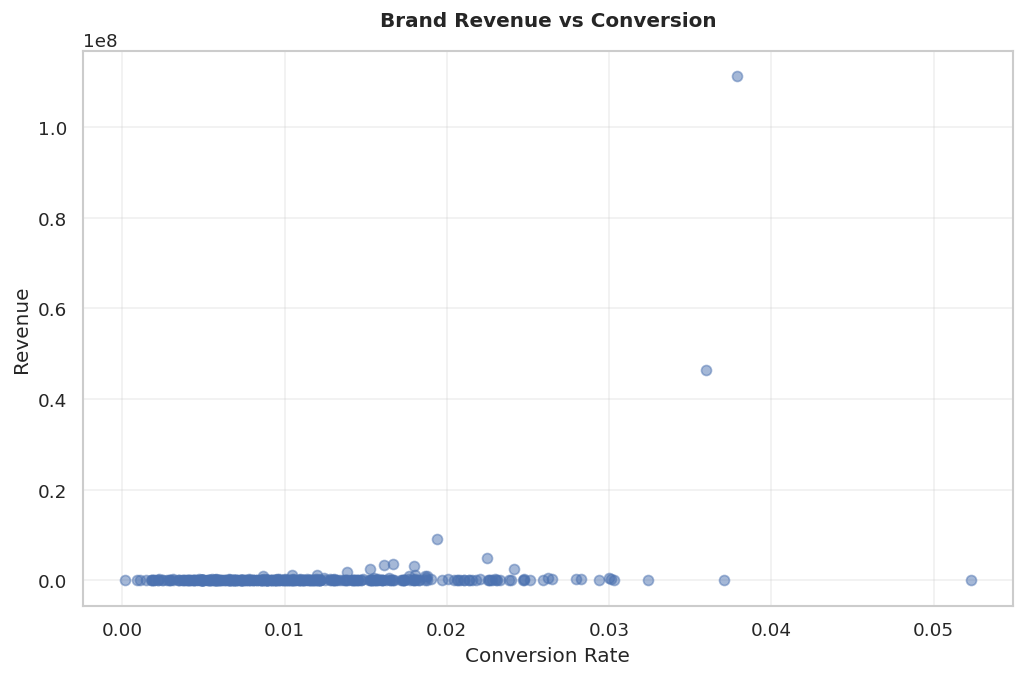

In [95]:
brand_plot = brand[
    brand["views"] >= 10000
].copy()

plt.figure(figsize=(10, 6))

plt.scatter(
    brand_plot["conversion_rate"],
    brand_plot["revenue"],
    alpha=0.5
)

plt.xlabel("Conversion Rate")
plt.ylabel("Revenue")
plt.title("Brand Revenue vs Conversion")

plt.grid(alpha=0.3)

plt.show()

In [96]:
# 2 brand có Revenue cao nhất
top_revenue = brand.nlargest(2, "revenue")

# 1 brand có Conversion Rate cao nhất nhưng Revenue = 0
top_conversion_zero_revenue = (
    brand[brand["revenue"] == 0]
    .nlargest(1, "conversion_rate")
)

outliers = pd.concat([
    top_revenue,
    top_conversion_zero_revenue
])

outliers[
    ["brand", "views", "purchases", "conversion_rate", "revenue"]
]

,brand,views,purchases,conversion_rate,revenue
1700,apple,3770597,142873,0.037891,1.112093e+08
4,samsung,4806630,172896,0.035970,4.640753e+07
97,a-elita,201,0,0.000000,0.000000e+00


###**Key Insights**
* Revenue tập trung rất mạnh ở một số ít brand, tạo ra các điểm outlier lớn.

* Conversion cao không đồng nghĩa Revenue cao: có brand conversion >3–5% nhưng revenue gần như bằng 0.

* Một số brand có Revenue rất cao dù conversion chỉ ở mức trung bình → quy mô traffic/sales volume đóng vai trò lớn.

👉 Conversion Rate một mình không đủ để đánh giá hiệu quả brand. Nên kết hợp Revenue + Conversion + Traffic để xác định brand thực sự có giá trị.

## 3.11. Hour-of-day Analysis

Phân tích conversion / purchase theo giờ trong ngày để hỗ trợ quyết định về timing của marketing và vận hành.


In [97]:
query = f"""
SELECT

    EXTRACT(
        HOUR FROM event_time::TIMESTAMP
    ) AS hour,

    COUNT(*) FILTER (
        WHERE event_type = 'view'
    ) AS views,

    COUNT(*) FILTER (
        WHERE event_type = 'purchase'
    ) AS purchases,

    SUM(
        CASE
            WHEN event_type = 'purchase'
            THEN price
            ELSE 0
        END
    ) AS revenue

FROM read_parquet('{parquet_path}')

GROUP BY hour
ORDER BY hour
"""

hourly = con.execute(query).df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

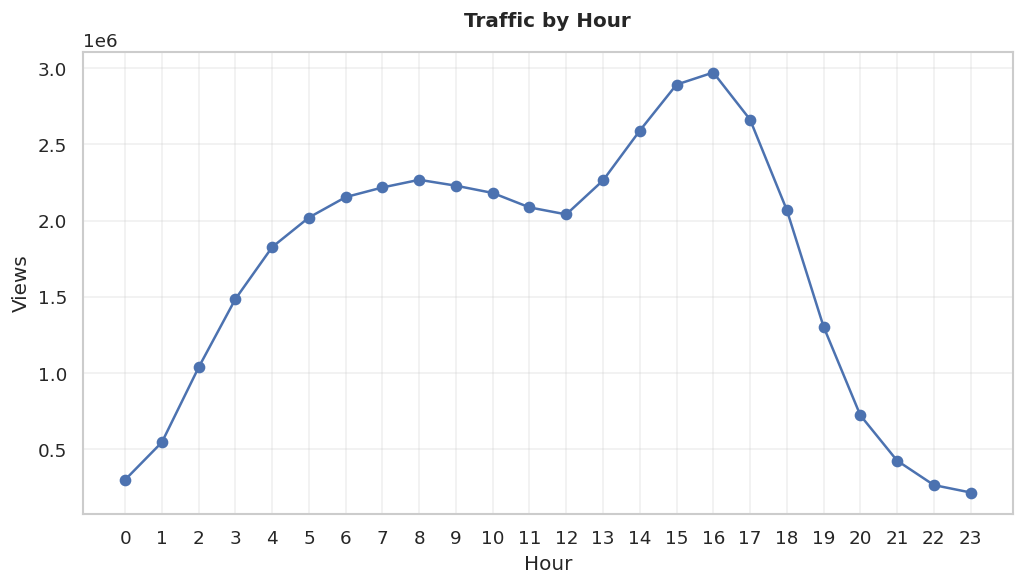

In [98]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly["hour"],
    hourly["views"],
    marker="o"
)

plt.xticks(range(24))

plt.xlabel("Hour")
plt.ylabel("Views")
plt.title("Traffic by Hour")

plt.grid(alpha=0.3)

plt.show()

###**Key Insights**
* Traffic tăng mạnh từ 0h → 8h, duy trì cao trong buổi sáng.

* Có một nhịp giảm nhẹ 9h → 12h, sau đó traffic tăng mạnh trở lại.

* 15h–17h là khung giờ cao điểm, đạt đỉnh khoảng 16h (~3 triệu views).

* Sau 18h, traffic giảm rất nhanh và thấp nhất vào khoảng 22h–23h.

👉 16h là peak traffic, phù hợp để ưu tiên marketing campaigns, push notifications và flash sales.

###**Recommendations**


* Marketing Campaign: Tập trung campaign vào 15h–17h, đặc biệt quanh 16h để tận dụng peak traffic.

* Push Notification: Gửi trước peak 30–60 phút để kéo traffic vào khung giờ cao điểm.

* Flash Sale: Ưu tiên 15h–17h, kết hợp các sản phẩm có conversion tốt để tối đa hóa hiệu quả.

* Giảm ngân sách vào 22h–23h, khi traffic xuống thấp.

* Kết hợp Traffic × Conversion để chọn thời điểm tối ưu, vì traffic cao chưa chắc conversion cao.

* Infrastructure Planning: Tăng capacity và monitoring trước 15h–17h để đảm bảo hệ thống chịu được peak traffic.


👉 Overall: Đồng bộ marketing + push + flash sale + infrastructure quanh khung 15h–17h, với 16h là thời điểm trọng tâm.



# PHẦN 4. KEY INSIGHTS

> **Mô hình D+1 tạo cơ sở để thử nghiệm ưu tiên khách active hằng ngày; các SKU chủ lực là nơi cần bảo vệ giá trị mua hiện có. Recommendation và mở rộng hiển thị sản phẩm là các hướng thử nghiệm tiếp theo. Funnel, giá và thời điểm tiếp cận cần thêm bằng chứng trước khi đầu tư lớn.**

## 4.1. Next-day purchase score hỗ trợ ưu tiên khách active cho CRM hằng ngày

**Kết quả dưới đây lấy từ output đã lưu của notebook modeling nguồn**, chưa phải một lần chạy mới của bản tích hợp. Bài toán: tại cuối ngày D, dự báo khách active trong D có purchase trong D+1.

- Sample khoảng **5% users**, giữ lịch sử quan sát; Train **244.035 user-days** (01–23/10), Test **71.050 user-days** (24–30/10), labels Test đến 31/10.
- **Random Forest** được chọn bằng time-based CV trong Train, sau tuning có **Test ROC-AUC 0,81725**, Train AUC **0,81022**, CV AUC **0,81534**.
- **Score PSI 0,03389** cho thấy phân phối score ít thay đổi theo cách chia bin này; không chứng minh model đã được calibration hoặc sẽ ổn định tháng sau.
- Cutoff **0,571473** được chọn bằng cost matrix trên Train OOF. Trên Test, chọn **12.386 user-days (17,43%)**, trong đó **934** có purchase D+1: precision **7,54%**, recall **62,77%**.
- So với base rate **2,09%**, precision nhóm được chọn cao khoảng **3,60×**. Đây là lift tại cutoff nguồn, **không phải Lift@Top 10%**.

**Hàm ý kinh doanh:** có thể thử ưu tiên reminder/retargeting vào D+1 cho khách vừa có hoạt động. Nhiều dòng có thể thuộc cùng một user ở các ngày khác nhau, vì vậy cần giới hạn tần suất liên hệ.

**Quyết định được hỗ trợ:** kiểm định lại pipeline, sau đó thử CRM ở quy mô giới hạn với đối chứng theo user. Kết quả chạy lại tại 3.7 và artifacts Gradio sẽ thay số tham chiếu khi báo cáo chính thức.

> AUC không phải accuracy. Score chưa calibration; score 0,57 không đồng nghĩa xác suất mua thực tế 57%. **18.256.000** là utility proxy từ giả định TP/FP/FN, chưa phải doanh thu hay lợi nhuận tăng thêm. Chưa có kết quả so sánh recency-only cho mô hình mới; không mang số 62% của mô hình tháng cũ sang đây.

---

## 4.2. Smartphone và các SKU Apple, Samsung chủ lực là nơi cần bảo vệ doanh thu hiện có

**Smartphone** dẫn đầu các category có nhãn, với khoảng **157,05 triệu giá trị mua ghi nhận**. Ở cấp sản phẩm:

- **Apple 1005115:** khoảng **12,41 triệu giá trị mua ghi nhận**.
- **Samsung 1004767:** khoảng **5,43 triệu giá trị mua ghi nhận** và **378.777 lượt xem**.

Các sản phẩm này có quy mô giao dịch hoặc mức độ quan tâm lớn, vì vậy một vấn đề về tồn kho, nội dung sản phẩm, giá, thanh toán hoặc giao hàng có thể ảnh hưởng đến lượng doanh thu đáng kể.

**Hàm ý kinh doanh:** trước khi tìm cơ hội tăng trưởng mới, doanh nghiệp nên bảo vệ khả năng chuyển đổi của những SKU đang tạo ra nhu cầu và giá trị mua lớn nhất.

**Quyết định được hỗ trợ:** đưa các SKU chủ lực vào danh sách giám sát ưu tiên về tồn kho, giá, lỗi hành trình mua và trải nghiệm trang sản phẩm.

> Giá trị mua ghi nhận chưa phản ánh lợi nhuận. Dữ liệu hiện tại cũng chưa chứng minh các SKU này đang thiếu hàng hoặc gặp lỗi vận hành; đây là những điểm cần kiểm tra thêm.

---

## 4.3. Apple 1004237 là ứng viên cụ thể để thử tăng hiển thị

**Apple 1004237** có **52.856 lượt xem** và tỷ số **purchase/view đạt 4,26%**, nổi bật trong nhóm sản phẩm có ít nhất 50.000 lượt xem.

Kết quả cho thấy lựa chọn sản phẩm để quảng bá chỉ dựa trên tổng lượt xem có thể bỏ qua một số SKU có tín hiệu mua tương đối tốt.

**Hàm ý kinh doanh:** Apple 1004237 là ứng viên phù hợp để thử xuất hiện nhiều hơn trên trang chủ, trang category, kết quả tìm kiếm hoặc recommendation.

**Quyết định được hỗ trợ:** thực hiện A/B test tăng hiển thị sản phẩm cho nhóm khách phù hợp, sau đó đo số giao dịch và lợi nhuận tăng thêm.

> “Hidden Gem” là nhãn tương đối trong tập sản phẩm có ít nhất 50.000 lượt xem. Purchase/view là tỷ số giữa các sự kiện, chưa phải xác suất một người xem sẽ mua và chưa bảo đảm hiệu suất giữ nguyên khi mở rộng traffic.

---

## 4.4. CRM nên kết hợp giá trị khách hàng, khả năng mua D+1 và sở thích sản phẩm

Phân tích RFM chia người đã mua thành:

- **Core: 80,8%**
- **High Value: 14,0%**
- **At Risk: 5,2%**

Mỗi phương pháp đang trả lời một câu hỏi khác nhau:

- **RFM:** khách hàng hiện thuộc nhóm giá trị nào?
- **Next-day model:** trong các khách active ngày D, nên ưu tiên ai cho D+1?
- **Recommendation baseline:** nên giới thiệu category hoặc sản phẩm nào?

Kết hợp ba kết quả này giúp doanh nghiệp thiết kế CRM cụ thể hơn:

| Nhóm | Mục tiêu kinh doanh | Cách sử dụng dữ liệu |
|---|---|---|
| High Value | Duy trì quan hệ và tần suất mua | Ưu tiên chăm sóc, quyền lợi hoặc sản phẩm phù hợp lịch sử mua |
| At Risk | Khuyến khích quay lại | Chỉ ghép score nếu khách active ngày D; khách vắng mặt nằm ngoài population model |
| Core | Tạo lần mua tiếp theo | Gợi ý sản phẩm theo category yêu thích |
| Score thấp | Hạn chế chi phí tiếp cận | Dùng kênh chi phí thấp hoặc chưa đưa vào chiến dịch giới hạn ngân sách |

**Hàm ý kinh doanh:** doanh nghiệp có thể chuyển từ gửi cùng một chương trình cho mọi khách sang lựa chọn **đúng khách – đúng mục tiêu – đúng sản phẩm**.

**Quyết định được hỗ trợ:** dùng RFM để xác định mục tiêu chăm sóc, model để xếp hạng đối tượng và recommendation để chọn nội dung sản phẩm.

> Khi kết hợp với score ngày D, phải tính RFM và sở thích bằng dữ liệu đến D. RFM toàn October chỉ là mô tả cuối tháng, không được ghép vào backtest các ngày trước đó. Khách active chưa từng mua có thể không có RFM; vẫn được model D+1 chấm điểm. High Value phản ánh giá trị theo RFM, chưa phải Customer Lifetime Value dự báo. At Risk là nhóm ưu tiên theo quy tắc, chưa xác nhận khách đã churn. Recommendation theo favorite category là baseline và cần được kiểm định bằng hành vi thực tế.

---

## 4.5. Funnel hiện tại chưa xác định được điểm thất thoát lớn nhất

Có **629.560 session chứa purchase**, nhiều hơn **573.097 session chứa cart**. Điều này cho thấy các tập session không lồng nhau và hành trình thực tế không phù hợp với giả định mọi giao dịch đều đi tuần tự qua:

**View → Cart → Purchase**

Vì vậy, tỷ số **6,20% cart/view sessions** không phải conversion rate từ View sang Cart và không thể dùng để kết luận **93,80% khách thất thoát trước bước thêm giỏ hàng**.

Một số purchase có thể không quan sát thấy cart trong dữ liệu. Tuy nhiên, trường hợp không quan sát cart cũng chưa đủ để kết luận người dùng đã sử dụng chức năng Buy Now.

**Hàm ý kinh doanh:** nếu dùng funnel hiện tại để chọn bước cần tối ưu, doanh nghiệp có nguy cơ đầu tư sai vị trí.

**Quyết định được hỗ trợ:** chưa chọn View → Cart hay Cart → Purchase làm bottleneck cho đến khi hành trình được dựng theo đúng **user–session–product** và thứ tự timestamp.

> Cần tách các đường mua có quan sát cart và không quan sát cart, sau đó mới tính conversion và mức thất thoát của từng bước.

---

## 4.6. Giá và thời điểm truy cập mới tạo ra giả thuyết, chưa đủ để quyết định ngân sách

Phân tích hiện tại ghi nhận peak hoạt động khoảng **15–17h UTC** và cho thấy hành vi mua khác nhau giữa các nhóm giá. Tuy nhiên, các kết quả quan sát chưa chứng minh:

- Gửi chiến dịch trong khung giờ này sẽ tạo thêm giao dịch.
- Giá cao trực tiếp làm conversion giảm.
- Giảm giá sẽ tạo đủ doanh thu tăng thêm để bù phần biên lợi nhuận mất đi.

Mối quan hệ giữa giá và conversion còn có thể chịu ảnh hưởng của category, brand, chất lượng sản phẩm, mức độ phổ biến và nhóm khách hàng.

**Hàm ý kinh doanh:** thời điểm tiếp cận và giá nên được xem là biến thử nghiệm, chưa phải quy tắc vận hành cố định.

**Quyết định được hỗ trợ:** thử nghiệm thời điểm gửi và ưu đãi trong phạm vi nhỏ; đánh giá cả conversion, doanh thu và lợi nhuận.

---

## 4.7. Kết luận theo các câu hỏi kinh doanh

| Câu hỏi kinh doanh | Kết luận hiện tại |
|---|---|
| Traffic và doanh thu thay đổi như thế nào theo thời gian? | Đã mô tả được biến động và khung giờ hoạt động cao, nhưng cần tách ảnh hưởng của traffic, conversion và giá trị đơn hàng để giải thích nguyên nhân doanh thu thay đổi. |
| Category, brand và product nào được quan tâm hoặc mua nhiều nhất? | Smartphone dẫn đầu category có nhãn; Apple 1005115 và Samsung 1004767 là các SKU chủ lực; Apple 1004237 là ứng viên thử tăng hiển thị. |
| Funnel thất thoát nhiều nhất ở bước nào? | Chưa thể xác định đáng tin cậy vì các tập View, Cart và Purchase không lồng nhau. |
| Giá sản phẩm có ảnh hưởng đến conversion không? | Có mối liên hệ quan sát được, nhưng chưa đủ bằng chứng để kết luận tác động nhân quả hoặc đề xuất giảm giá diện rộng. |
| Khách hàng nào có giá trị cao hoặc có nguy cơ không quay lại? | RFM mô tả High Value và At Risk; model D+1 xếp hạng khách active, gồm cả khách chưa từng mua. Không dùng score thấp để kết luận churn. |
| Session nào có khả năng chuyển đổi; khách active nào có thể mua D+1? | 3.6 mô tả khác biệt giữa session hồi cứu. 3.7 dự báo user-day D+1: kết quả nguồn Test AUC 0,81725; precision 7,54%, recall 62,77% tại cutoff nguồn. |
| Nên đề xuất sản phẩm nào cho từng khách hàng? | Có thể bắt đầu bằng favorite category và các sản phẩm phổ biến trong category đó; cần A/B test trước khi tự động hóa. |

> Phần 3.7 trả lời **“Khách active ngày D nào có khả năng mua ngày D+1?”**. Phần 3.6 là phân tích session hồi cứu; chưa có mô hình dự báo trực tiếp một session đang diễn ra.

---



# PHẦN 5. RECOMMENDATIONS

> **Ưu tiên triển khai theo thứ tự: thử nghiệm CRM bằng model, bảo vệ SKU chủ lực, thử tăng hiển thị Hidden Gem, hoàn thiện đo lường funnel, sau đó mới thử nghiệm giá và thời điểm tiếp cận.**

## 5.1. Chạy pilot CRM bằng next-day purchase score

### Mục tiêu

Đo liệu chiến dịch với khách active được xếp hạng cao có tạo **purchase D+1 tăng thêm**, doanh thu và contribution margin sau chi phí hay không.

### Cách triển khai

1. Chạy lại 3.7, kiểm tra temporal Test, 24 features, cutoff và scope sample. Trong kết quả nguồn, cutoff 0,571473 liên hệ 17,43% user-days; đây không phải ngân sách cố định cho mọi ngày.
2. Sau khi dữ liệu ngày D (UTC) hoàn tất, tạo features đến D cho user active. Áp dụng cùng model version và cutoff đã khóa; scoring phải kết thúc trước thời điểm gửi chiến dịch D+1.
3. Chỉ dùng thông tin có đến D cho eligibility, RFM, recommendation và giới hạn tần suất. Không dùng actual D+1 để chọn người nhận.
4. Chốt utility assumptions với business: TP value, FP cost, FN cost cùng đơn vị; bổ sung chi phí contact cho mọi đối tượng, margin, ưu đãi và giới hạn ngân sách khi thiết kế kinh tế thực tế.
5. Trong tập đủ điều kiện, **randomize theo user một lần và giữ nhóm cố định suốt pilot**: treatment nhận chiến dịch, control không nhận chiến dịch đó. Không random lại từng user-day khiến một người đi qua cả hai nhóm.
6. Gửi trong D+1, thu nhãn sau khi D+1 kết thúc. Đăng ký trước KPI, cửa sổ đo, frequency cap và cách xử lý người lặp ngày. Nếu so model với rule, giữ cùng eligibility/ngân sách và đối chứng cho từng chính sách.

### KPI chính

- Incremental D+1 purchase rate, buyers, revenue và contribution margin.
- Chi phí trên buyer tăng thêm; unsubscribe/opt-out và tần suất contact.
- Chẩn đoán model: ROC-AUC, AP so với base rate, precision, recall, contact rate; PSI và drift features theo ngày/tuần.
- Phân tích uncertainty theo **user**, vì các quan sát user-day không độc lập.

### Nguyên tắc quyết định

Chỉ mở rộng sau khi chạy lại pipeline thành công, kiểm định thêm giai đoạn độc lập và pilot tạo lợi ích tăng thêm vượt chi phí. Score cao dự báo ai có thể mua, chưa cho biết ai sẽ thay đổi hành vi nhờ voucher. Utility proxy trong notebook không thay thế A/B test.

---

## 5.2. Thiết lập danh sách giám sát các SKU chủ lực

### Mục tiêu

Giảm rủi ro mất doanh thu tại các sản phẩm đang có giá trị mua hoặc lượng quan tâm lớn.

### Phạm vi ban đầu

- Apple 1005115.
- Samsung 1004767.
- Các SKU đứng đầu tiếp theo theo giá trị mua và lượt xem.

### Hạng mục cần kiểm tra

- Tỷ lệ còn hàng và số ngày hết hàng.
- Mức giá và biến động giá.
- Nội dung, hình ảnh và thông số sản phẩm.
- Tốc độ tải và lỗi trang sản phẩm.
- Lỗi thêm giỏ hàng và thanh toán.
- Chi phí giao hàng và thời gian giao dự kiến.
- Tỷ lệ hủy hoặc hoàn trả nếu có dữ liệu.
- Biên lợi nhuận của từng SKU.

### KPI chính

- Product availability.
- Purchase rate theo SKU.
- Giá trị mua và lợi nhuận theo SKU.
- Tỷ lệ lỗi trong hành trình mua.
- Tỷ lệ hủy và hoàn trả.

### Nguyên tắc quyết định

Ưu tiên xử lý các vấn đề có thể kiểm soát được tại SKU có quy mô giao dịch lớn nhất. Chỉ tăng thêm ngân sách quảng bá sau khi kiểm tra tồn kho, trải nghiệm mua và biên lợi nhuận.

---

## 5.3. A/B test tăng hiển thị Apple 1004237

### Mục tiêu

Kiểm tra liệu tăng mức độ xuất hiện của một sản phẩm có purchase/view tương đối cao có tạo thêm giao dịch và lợi nhuận hay không.

### Thiết kế đề xuất

- **Control:** giữ nguyên vị trí và tần suất hiển thị.
- **Treatment:** tăng hiển thị tại trang category, kết quả tìm kiếm hoặc recommendation.
- Phân bổ người dùng ngẫu nhiên và giữ trải nghiệm nhất quán trong thời gian test.
- Tránh đồng thời thay đổi giá, nội dung và vị trí hiển thị để có thể giải thích kết quả.

### KPI chính

- Click-through rate.
- Unique product viewers.
- Purchase rate theo người dùng.
- Số giao dịch tăng thêm.
- Doanh thu và lợi nhuận tăng thêm.
- Cannibalization: doanh số của SKU khác bị thay thế.
- Tỷ lệ hết hàng trong thời gian test.

### Nguyên tắc quyết định

Mở rộng hiển thị khi sản phẩm tạo thêm tổng giao dịch hoặc lợi nhuận của toàn nhóm sản phẩm, thay vì chỉ chuyển đơn hàng từ SKU khác sang Apple 1004237.

---

## 5.4. Cá nhân hóa CRM theo ba lớp dữ liệu

### Mục tiêu

Tăng mức độ phù hợp của thông điệp và sản phẩm được giới thiệu cho từng khách hàng.

### Cấu trúc đề xuất

| Lớp dữ liệu | Vai trò | Output sử dụng |
|---|---|---|
| RFM đến D | Xác định mục tiêu chăm sóc | High Value, Core, At Risk; chưa mua = chưa có RFM mua hàng |
| Next-day purchase score | Ưu tiên khách active ngày D | Score D+1, cutoff đã khóa, frequency cap |
| Recommendation đến D | Chọn nội dung sản phẩm | Favorite category / top sellers chỉ đến cutoff D |

### Kịch bản thử nghiệm

- **High Value + score cao:** giới thiệu sản phẩm phù hợp lịch sử mua và quyền lợi chăm sóc.
- **At Risk + active ngày D + score cao:** thử thông điệp nhắc quay lại hoặc ưu đãi có giới hạn. Khách không active ngày D cần chiến lược reactivation riêng.
- **Core + score cao:** gợi ý sản phẩm trong favorite category.
- **Score thấp:** sử dụng kênh chi phí thấp hoặc giảm tần suất tiếp cận.

### KPI chính

- Click-through rate.
- Conversion rate sau khi nhận recommendation.
- Revenue per recipient.
- Incremental revenue per recipient.
- Diversity và coverage của recommendation.
- Unsubscribe hoặc opt-out rate.

### Nguyên tắc quyết định

So sánh recommendation cá nhân hóa với baseline sản phẩm phổ biến. Chỉ tự động hóa khi cá nhân hóa tạo thêm giá trị và không làm tăng phản hồi tiêu cực.

---

## 5.5. Xây dựng lại funnel theo hành trình thực tế

### Mục tiêu

Xác định đúng đường mua và điểm thất thoát để tránh ưu tiên sai vấn đề.

### Đơn vị phân tích

Ghép sự kiện theo:

**user_id + user_session + product_id + event_time**

Sau đó sắp xếp sự kiện theo timestamp để phân biệt các đường:

- View → Cart → Purchase.
- View → Purchase không quan sát cart.
- Cart → Purchase khi không quan sát view.
- Purchase không quan sát view hoặc cart.
- View hoặc Cart nhưng không tạo purchase.

### Output cần bổ sung

- Số user–session–product trong từng đường.
- Tỷ trọng từng đường mua.
- Conversion của từng bước trên đúng tập đủ điều kiện.
- Thời gian từ View → Cart và Cart → Purchase.
- Breakdown theo category, device, nguồn traffic và nhóm giá nếu có dữ liệu.

### KPI chất lượng dữ liệu

- Tỷ lệ purchase ghép được với view trước đó.
- Tỷ lệ purchase ghép được với cart trước đó.
- Tỷ lệ event thiếu user_id, session_id hoặc product_id.
- Tỷ lệ timestamp không hợp lệ hoặc sai thứ tự.
- Tỷ lệ session bị cắt ở ranh giới thời gian dữ liệu.

### Nguyên tắc quyết định

Chỉ gọi một bước là bottleneck khi mẫu số, thứ tự thời gian và phạm vi quan sát đã được xác định rõ. “Không quan sát cart” nên được báo cáo đúng tên, chưa gắn nhãn Buy Now nếu không có event riêng.

---

## 5.6. Chỉ thử nghiệm giá trong phạm vi kiểm soát

### Mục tiêu

Đo tác động của thay đổi giá đến conversion và lợi nhuận, đồng thời hạn chế ảnh hưởng của category, brand và chất lượng sản phẩm.

### Cách triển khai

1. Chọn một nhóm SKU có tồn kho ổn định và đủ traffic.
2. Ưu tiên so sánh trong cùng SKU hoặc các SKU tương đồng.
3. Thử một mức thay đổi giá nhỏ hoặc ưu đãi có thời hạn.
4. Phân bổ người dùng hoặc khu vực thử nghiệm theo thiết kế phù hợp.
5. Theo dõi cả conversion và lợi nhuận.

### KPI chính

- Conversion uplift.
- Units sold.
- Revenue uplift.
- Gross profit hoặc contribution margin.
- Average order value.
- Cannibalization giữa các SKU.
- Tỷ lệ mua lại sau ưu đãi.

### Nguyên tắc quyết định

Không dùng conversion làm KPI duy nhất. Một chương trình giảm giá chỉ nên mở rộng khi phần doanh thu hoặc lợi nhuận tăng thêm bù được chi phí ưu đãi.

---

## 5.7. Thử nghiệm thời điểm gửi thay vì mặc định dùng giờ peak

### Mục tiêu

Xác định thời điểm tiếp cận tạo ra phản hồi và giao dịch tốt nhất.

### Thiết kế đề xuất

Chia ngẫu nhiên khách đủ điều kiện vào các khung giờ:

- Trước peak.
- Trong peak **15–17h UTC**.
- Sau peak.
- Nhóm không nhận thông báo nếu cần đo tác động tăng thêm.

Giữ nguyên nội dung, đối tượng và kênh để tách ảnh hưởng của thời điểm gửi.

### KPI chính

- Open rate hoặc view rate.
- Click-through rate.
- Purchase rate.
- Incremental revenue per recipient.
- Unsubscribe hoặc opt-out rate.

### Nguyên tắc quyết định

Chỉ áp dụng khung giờ peak làm mặc định nếu nó tạo ra kết quả tốt hơn trong thử nghiệm. Lượng truy cập cao không đồng nghĩa chiến dịch gửi vào thời điểm đó sẽ tạo thêm doanh thu.

---

## 5.8. Thứ tự ưu tiên triển khai

| Ưu tiên | Hành động | Lý do | Kết quả cần có |
|---:|---|---|---|
| 1 | A/B test CRM bằng next-day purchase score | Nguồn có tín hiệu xếp hạng D+1; chạy lại và xác nhận trên giai đoạn khác trước mở rộng | Incremental buyers, revenue và profit |
| 2 | Kiểm tra SKU chủ lực | Bảo vệ phần nhu cầu và giá trị mua đang hiện hữu | Danh sách vấn đề vận hành và tác động theo SKU |
| 3 | Test tăng hiển thị Apple 1004237 | Có ứng viên sản phẩm cụ thể để thử mở rộng | Incremental profit và cannibalization |
| 4 | Xây dựng lại funnel | Cần thiết để xác định đúng điểm nghẽn | Funnel theo user–session–product và timestamp |
| 5 | Test recommendation cá nhân hóa | Đã có favorite-category baseline | Uplift so với popular-product baseline |
| 6 | Test thời điểm gửi | Peak time hiện chỉ là tín hiệu quan sát | Khung giờ tạo phản hồi tăng thêm |
| 7 | Test giá có kiểm soát | Rủi ro ảnh hưởng biên lợi nhuận và nhiễu cao | Price elasticity và incremental profit |

---

## 5.9. Lộ trình thực hiện đề xuất

### Giai đoạn 1: Chuẩn bị đo lường

- Chốt định nghĩa customer, buyer, session, conversion và revenue.
- Xây dựng lại funnel theo user–session–product và timestamp.
- Kiểm tra tồn kho, lợi nhuận và lỗi dữ liệu của SKU chủ lực.
- Thiết lập quy trình chấm next-day purchase score cuối D, 24 features và artifact version dùng chung với Gradio.

### Giai đoạn 2: Chạy các thử nghiệm ưu tiên

- Chạy CRM experiment trên top nhóm khách theo model.
- A/B test tăng hiển thị Apple 1004237.
- So sánh recommendation theo favorite category với sản phẩm phổ biến.
- Thử các khung giờ gửi khác nhau.

### Giai đoạn 3: Đánh giá và mở rộng

- Đánh giá bằng incremental buyers, revenue và profit.
- Kiểm tra kết quả theo customer segment và product category.
- Mở rộng chiến lược thắng cuộc theo từng bước.
- Chấm điểm mỗi ngày; theo dõi theo ngày/tuần, đánh giá thêm tháng độc lập và retrain khi bằng chứng drift/suy giảm đủ rõ.
- Dừng hoặc điều chỉnh các can thiệp không tạo giá trị tăng thêm.

---

## 5.10. Kết luận hành động

Kết quả phân tích hỗ trợ ba hướng hành động chính:

1. **Tăng hiệu quả CRM:** dùng next-day purchase model để ưu tiên khách hàng, RFM để xác định mục tiêu chăm sóc và recommendation để chọn sản phẩm.
2. **Bảo vệ và mở rộng doanh thu sản phẩm:** giám sát các SKU chủ lực, đồng thời thử tăng hiển thị cho Apple 1004237.
3. **Nâng chất lượng quyết định:** hoàn thiện funnel và dùng thử nghiệm đối chứng để đánh giá CRM, recommendation, giá và thời điểm tiếp cận.

Ưu tiên trước mắt là chạy lại pipeline D+1 và chuẩn bị pilot CRM với nhóm đối chứng; kết quả nguồn mới chỉ là backtest ngắn trong October. Song song, doanh nghiệp nên kiểm tra các SKU chủ lực và hoàn thiện đo lường funnel. Các quyết định mở rộng ngân sách, giảm giá hoặc tự động hóa chỉ nên được thực hiện sau khi chứng minh được tác động tăng thêm đến doanh thu hoặc lợi nhuận.